In [1]:
import uproot
import awkward as ak
import hist
import mplhep
import matplotlib.pyplot as plt
import numpy as np
from mt2 import mt2
from scipy.optimize import minimize
# from scipy import optimize
from scipy.optimize import brute
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt

In [32]:
muon_mass = .10566
ttom_decay = 0.1739
ttoj_decay = 0.6479
t_tag = 0.8
j_mistag = 0.02
wtom_decay = 0.1063
wtot_decay = 0.1138
wtoj_decay = 0.6741
# mnt_dir = "/Users/katherinefraser/mnt/ody7/Event_Generation/MadGraph5/MG5_aMC_v3_5_3/Outputs/"
# local_dir = "/Users/katherinefraser/Documents/Physics_by_Subject/Colliders/Projects/2024_LFV-at-MuC/Final_FF/mumumuta/"


def get_tree(folder_name, path):
    file_name = path + folder_name + \
    "/Events/run_01/tag_1_delphes_events.root"
    file = uproot.open(file_name)
    return file["Delphes"]


def get_muons(tree):
    return ak.zip({"pt": tree["Muon.PT"].array(), "eta": tree["Muon.Eta"].array(), \
                  "phi": tree["Muon.Phi"].array(), "charge":tree["Muon.Charge"].array(),})

def get_electrons(tree):
    return ak.zip({"pt": tree["Electron.PT"].array(), "eta": tree["Electron.Eta"].array(), \
                  "phi": tree["Electron.Phi"].array(), "charge":tree["Electron.Charge"].array(),})

#def get_jets(tree):
#    return ak.zip({"pt": tree["Jet.PT"].array(), "eta": tree["Jet.Eta"].array(), \
#                  "phi": tree["Jet.Phi"].array(), "charge":tree["Jet.Charge"].array(),})

# def get_jets(tree):
#     return ak.zip({"pt": tree["KTjet.PT"].array(), "eta": tree["KTjet.Eta"].array(), \
#                   "phi": tree["KTjet.Phi"].array(), "charge":tree["KTjet.Charge"].array(),
#                   "mass": tree["KTjet.Mass"].array(),})

def get_jets(tree):
    return ak.zip({"pt": tree["KTjet.PT"].array(), "eta": tree["KTjet.Eta"].array(), \
                  "phi": tree["KTjet.Phi"].array(), "charge":tree["KTjet.Charge"].array(),
                  "mass": tree["KTjet.Mass"].array(),})


def get_met(tree):
    return ak.zip({"met": tree["MissingET.MET"].array(), "eta": tree["MissingET.Eta"].array(), \
                  "phi": tree["MissingET.Phi"].array(),})

def get_particles(tree):
    return(get_muons(tree),get_electrons(tree),get_jets(tree),get_met(tree))

# Delete empty awkward array elements (use for histograms, be careful not to ruin indexing)
def delete_empty(array_name):
    return array_name[ak.num(array_name,axis=1)>0]

# Works for any number of muons, but only one met elt
def compute_min_alignment(met_array, muon_array):
    # Example input arrays
    array1 = met_array
    array2 = muon_array

    # Compute the number of elements in each row of array2
    counts = ak.num(array2)

    # Duplicate elements in array1 to match the counts of array2
    expanded_array1 = ak.Array([[x[0]] * c for x, c in zip(array1, counts)])

    return expanded_array1-array2

# Only works for any number of muons, but exactly one met elt
def compute_delta_R(met_array_eta, met_array_phi, muon_array_eta, muon_array_phi):
    # Example input arrays
    deltaR = (compute_min_alignment(met_array_eta, muon_array_eta)**2 + compute_min_alignment(met_array_phi, muon_array_phi)**2)**(1/2)

    return deltaR

# Only works if fixed number of particles
def compute_E(eta_array, pt_array,m):
    pz = pt_array* np.sinh(eta_array)
    Energy = np.sqrt(pz**2 + pt_array**2 + m**2)
    return Energy

def extract_data(data_tree, lepton_isolation_val = 0.4):
    #Extract data and filter to have one muon and one isolated tau jet
    (data_muons,data_electrons,data_jets,data_met) = get_particles(data_tree)
    two_jet_condit=ak.num(data_jets,axis=1)==2
    
    muons_eta = data_muons["eta"][two_jet_condit]
    muons_phi = data_muons["phi"][two_jet_condit]
    muons_pt = data_muons["pt"][two_jet_condit]
    jets_eta = data_jets["eta"][two_jet_condit]
    jets_phi = data_jets["phi"][two_jet_condit]
    jets_pt = data_jets["pt"][two_jet_condit]
    jets_mass = data_jets["mass"][two_jet_condit]
    met = data_met["met"][two_jet_condit]
    met_eta = data_met["eta"][two_jet_condit]
    met_phi = data_met["phi"][two_jet_condit]
    num = len(data_tree["Particle"].array())

    # Compute observables
    #Fix with axis label
    diff_eta =  abs(compute_min_alignment(met_eta, jets_eta))
    #Fix with axis label
    diff_R = compute_delta_R(met_eta, met_phi, jets_eta, jets_phi)
    Eval = compute_E(jets_eta, jets_pt, jets_mass)
    
    mt2_val = mt2(jets_mass[:,0], jets_pt[:,0] *np.cos(jets_phi[:,0]), jets_pt[:,0] *np.sin(jets_phi[:,0]),  # Visible 1: mass, px, py
    jets_mass[:,1], jets_pt[:,1]*np.cos(jets_phi[:,1]), jets_pt[:,1]*np.sin(jets_phi[:,1]),  # Visible 2: mass, px, py
    met*np.cos(met_phi), met*np.sin(met_phi),  # Missing transverse momentum: x, y
    0, 0)  # Invisible 1 mass, invisible 2 mass
    
    # Print total # of events and # of one muon events
    print(num, ",", ak.sum(two_jet_condit))
    
    return (muons_eta, muons_phi, muons_pt, jets_eta, jets_phi, jets_pt, jets_mass,\
           met_eta, met_phi, met, num, diff_eta, diff_R, Eval, mt2_val
           )
    
def impose_eta_cut(prefix, postfix, min_eta, max_eta):
    var_name = prefix + "_diff" + postfix
    array = globals()[var_name]
    cuts = (array > min_eta) & (array < max_eta)
    # return (ak.sum(ak.unflatten(cuts[:,0], counts=1)),ak.sum(ak.unflatten(cuts[:,1], counts=1)), cuts)
    return (ak.sum(cuts[:,0]),ak.sum(cuts[:,1]), cuts)

def impose_lower_cut_2D(var_name, cut_val):
    array = globals()[var_name]
    cuts = (array > cut_val)
    return (ak.sum(ak.unflatten(cuts[:,0], counts=1)),ak.sum(ak.unflatten(cuts[:,1], counts=1)), cuts)
    
def impose_lower_cut(var_name, cut_val):
    array = globals()[var_name]
    cuts = (array > cut_val)
    return (ak.sum(cuts), cuts)

def impose_lower_cut_abs(var_name, cut_val):
    array = abs(globals()[var_name])
    cuts = (array > cut_val)
    return (ak.sum(cuts), cuts)

def impose_lower_cut_arr(arr_name, cut_val):
    array = arr_name
    cuts = (array > cut_val)
    return (ak.sum(cuts), cuts)

def impose_upper_cut(var_name, cut_val):
    array = globals()[var_name]
    cuts = (array < cut_val)
    return (ak.sum(cuts), cuts)

In [60]:
#bkg_tree_muWtauW = uproot.open("/Users/hengameh/Downloads/MG5_aMC_v3_5_3/workingDir/unweighted_events_ceW_backg.root")["Delphes"]
# sig_tree_muWtauW = uproot.open("/Users/hengameh/Downloads/MG5_aMC_v3_5_3/workingDir/unweighted_events_ceW_sig.root")["Delphes"]
# Sam's:
sig_tree_muWtauW = uproot.open("/Users/hengameh/Downloads/MG5_aMC_v3_5_3/workingDir/recon_events_cew-01.root")["Delphes"]
sig_tree_cHL3 = uproot.open("/Users/hengameh/Downloads/MG5_aMC_v3_5_3/workingDir/unweighted_events_cHL3.root")["Delphes"]
sig_tree_cHL1 = uproot.open("/Users/hengameh/Downloads/MG5_aMC_v3_5_3/workingDir/unweighted_events_cHL1.root")["Delphes"]
# sig_tree_cHe = uproot.open("/Users/hengameh/Downloads/MG5_aMC_v3_5_3/workingDir/unweighted_events_cHe.root")["Delphes"]
sig_tree_cHe = uproot.open("/Users/hengameh/Downloads/MG5_aMC_v3_5_3/workingDir/muw_taw-che_recon_events-01.root")["Delphes"]
# sig_tree_cHe = uproot.open("/Users/hengameh/Downloads/MG5_aMC_v3_5_3/workingDir/muw_taw-che-run-01.root")["Delphes"]

#bkg_tree_muWtauW_neutVBF = uproot.open("/Users/hengameh/Downloads/MG5_aMC_v3_5_3/workingDir/unweighted_events_neutVBF.root")["Delphes"]
#bkg_tree_muWtauW_chargedVBF = uproot.open("/Users/hengameh/Downloads/MG5_aMC_v3_5_3/workingDir/unweighted_events_chargedVBF.root")["Delphes"]
#bkg_tree_muWtauW_annihilation = uproot.open("/Users/hengameh/Downloads/MG5_aMC_v3_5_3/workingDir/unweighted_events_annihilation.root")["Delphes"]

# bkg_tree_cHe = uproot.open("/Users/hengameh/Downloads/MG5_aMC_v3_5_3/workingDir/recon_events_che-01.root")["Delphes"]
# bkg_tree_cHe50k = uproot.open("/Users/hengameh/Downloads/MG5_aMC_v3_5_3/workingDir/unweighted_events_backg_ceW50k.root")["Delphes"]
stacked_anni = uproot.open("/Users/hengameh/Downloads/MG5_aMC_v3_5_3/combined.root")["Delphes"]
stacked_VBF = uproot.open("/Users/hengameh/Downloads/MG5_aMC_v3_5_3/combinedVBF.root")["Delphes"]
stacked_VBF_neut = uproot.open("/Users/hengameh/Downloads/MG5_aMC_v3_5_3/combinedVBF_neut.root")["Delphes"]


In [61]:
# (bkg_muons_eta, bkg_muons_phi, bkg_muons_pt, bkg_jets_eta, bkg_jets_phi, \
#  bkg_jets_pt, bkg_jets_mass, bkg_met_eta, bkg_met_phi, bkg_met, \
#  bkg_num, bkg_diff, bkg_R, bkg_muons_E, bkg_mt2) = extract_data(bkg_tree_cHe50k)

(sig_muons_eta, sig_muons_phi, sig_muons_pt, sig_jets_eta, sig_jets_phi, \
 sig_jets_pt, sig_jets_mass, sig_met_eta, sig_met_phi, sig_met, \
 sig_num, sig_diff, sig_R ,sig_muons_E, sig_mt2 ) = extract_data(sig_tree_muWtauW)

(sigcHL3_muons_eta, sigcHL3_muons_phi, sigcHL3_muons_pt, sigcHL3_jets_eta, sigcHL3_jets_phi, \
 sigcHL3_jets_pt, sigcHL3_jets_mass, sigcHL3_met_eta, sigcHL3_met_phi, sigcHL3_met, \
 sigcHL3_num, sigcHL3_diff, sigcHL3_R ,sigcHL3_muons_E, sigcHL3_mt2 ) = extract_data(sig_tree_cHL3)

(sigcHL1_muons_eta, sigcHL1_muons_phi, sigcHL1_muons_pt, sigcHL1_jets_eta, sigcHL1_jets_phi, \
 sigcHL1_jets_pt, sigcHL1_jets_mass, sigcHL1_met_eta, sigcHL1_met_phi, sigcHL1_met, \
 sigcHL1_num, sigcHL1_diff, sigcHL1_R ,sigcHL1_muons_E, sigcHL1_mt2 ) = extract_data(sig_tree_cHL1)

(sigcHe_muons_eta, sigcHe_muons_phi, sigcHe_muons_pt, sigcHe_jets_eta, sigcHe_jets_phi, \
 sigcHe_jets_pt, sigcHe_jets_mass, sigcHe_met_eta, sigcHe_met_phi, sigcHe_met, \
 sigcHe_num, sigcHe_diff, sigcHe_R ,sigcHe_muons_E, sigcHe_mt2) = extract_data(sig_tree_cHe)

# (bkgVBFneut_muons_eta, bkgVBFneut_muons_phi, bkgVBFneut_muons_pt, bkgVBFneut_jets_eta, bkgVBFneut_jets_phi, \
#  bkgVBFneut_jets_pt, bkgVBFneut_jets_mass, bkgVBFneut_met_eta, bkgVBFneut_met_phi, bkgVBFneut_met, \
#  bkgVBFneut_num, bkgVBFneut_diff, bkgVBFneut_R, bkgVBFneut_muons_E, bkgVBFneut_mt2) = extract_data(bkg_tree_muWtauW_neutVBF)

(bkgVBFneut_muons_eta, bkgVBFneut_muons_phi, bkgVBFneut_muons_pt, bkgVBFneut_jets_eta, bkgVBFneut_jets_phi, \
 bkgVBFneut_jets_pt, bkgVBFneut_jets_mass, bkgVBFneut_met_eta, bkgVBFneut_met_phi, bkgVBFneut_met, \
 bkgVBFneut_num, bkgVBFneut_diff, bkgVBFneut_R, bkgVBFneut_muons_E, bkgVBFneut_mt2) = extract_data(stacked_VBF_neut)

# (bkgVBFcharge_muons_eta, bkgVBFcharge_muons_phi, bkgVBFcharge_muons_pt, bkgVBFcharge_jets_eta, bkgVBFcharge_jets_phi, \
#  bkgVBFcharge_jets_pt, bkgVBFcharge_jets_mass, bkgVBFcharge_met_eta, bkgVBFcharge_met_phi, bkgVBFcharge_met, \
#  bkgVBFcharge_num, bkgVBFcharge_diff, bkgVBFcharge_R, bkgVBFcharge_muons_E, bkgVBFcharge_mt2) = extract_data(bkg_tree_muWtauW_chargedVBF)

(bkgVBFcharge_muons_eta, bkgVBFcharge_muons_phi, bkgVBFcharge_muons_pt, bkgVBFcharge_jets_eta, bkgVBFcharge_jets_phi, \
 bkgVBFcharge_jets_pt, bkgVBFcharge_jets_mass, bkgVBFcharge_met_eta, bkgVBFcharge_met_phi, bkgVBFcharge_met, \
 bkgVBFcharge_num, bkgVBFcharge_diff, bkgVBFcharge_R, bkgVBFcharge_muons_E, bkgVBFcharge_mt2) = extract_data(stacked_VBF)

# (bkgAnni_muons_eta, bkgAnni_muons_phi, bkgAnni_muons_pt, bkgAnni_jets_eta, bkgAnni_jets_phi, \
#  bkgAnni_jets_pt, bkgAnni_jets_mass, bkgAnni_met_eta, bkgAnni_met_phi, bkgAnni_met, \
#  bkgAnni_num, bkgAnni_diff, bkgAnni_R, bkgAnni_muons_E, bkgAnni_mt2) = extract_data(bkg_tree_muWtauW_annihilation)

(bkgAnni_muons_eta, bkgAnni_muons_phi, bkgAnni_muons_pt, bkgAnni_jets_eta, bkgAnni_jets_phi, \
 bkgAnni_jets_pt, bkgAnni_jets_mass, bkgAnni_met_eta, bkgAnni_met_phi, bkgAnni_met, \
 bkgAnni_num, bkgAnni_diff, bkgAnni_R, bkgAnni_muons_E, bkgAnni_mt2) = extract_data(stacked_anni)


# sig_CeW
#sig_cHL3
#sig_cHL1
#sig_cHe
# bckg_neutVBF
# bckg_chargedVBF
# bckg_anni

50000 , 44907
10000 , 9909
10000 , 9909
50000 , 45847
250000 , 142893
205343 , 64702
32115 , 7241


In [72]:
###################
#Random Prints here
###################
(data_muons,data_electrons,data_jets,data_met) = get_particles(bkg_tree_muWtauW)
two_jet_condit=ak.num(data_jets,axis=1)==2
jets_eta = data_jets["eta"][two_jet_condit]
met_eta = data_met["eta"][two_jet_condit]
met_phi = data_met["phi"][two_jet_condit]
jets_phi = data_jets["phi"][two_jet_condit]

diff_eta =  abs(compute_min_alignment(met_eta, jets_eta))
diff_R = compute_delta_R(met_eta, met_phi, jets_eta, jets_phi)
# print(diff_eta[:,1])
# print(jets_eta[:,0])
# print(ak.unflatten(jets_eta[:,0], counts=1))
# print(np.sum(ak.num(bkg_met_eta)))
# print(np.sum(ak.num(bkg_mt2)))
# print(bkg_met)

# print(bkg_jets_pt)
# print(sig_jets_pt)

# ak.sum(bkg_jets_pt[:,1]<bkg_jets_pt[:,0])
print(sig_jets_pt)
print(sig_R)

[[1.62e+03, 1.3e+03], [1.83e+03, 1.54e+03], ..., [...], [2.71e+03, 1.02e+03]]
[[3.72, 4.68], [3.71, 4.22], [2.95, ...], ..., [5.45, 2.93], [4.05, 0.711]]


In [69]:
print(abs(compute_min_alignment(met_eta, ak.unflatten(jets_eta[:,1], counts=1))))

[[0.048], [2.69], [0.0546], [0.0419], ..., [0.423], [0.0239], [0.333], [0.0664]]


In [29]:
print(bkg_tree_muWtauW["Particle.PID"].array()[bkg_tree_muWtauW["Particle.Status"].array()==1][20])
print(sig_tree_muWtauW["Particle.PID"].array()[sig_tree_muWtauW["Particle.Status"].array()==1][20])

bkg_tree_muWtauW.keys()
sig_tree_muWtauW.keys()

[22, 16, -16, -16, 211, 16, -211, -211, 211, 22, 22, 22, 22]
[-14, 16, -211, 22, 22, -321, -211, -211, ..., 22, 22, 22, 22, 22, 22, 22, 22]


['Event',
 'Event/Event.fUniqueID',
 'Event/Event.fBits',
 'Event/Event.Number',
 'Event/Event.ReadTime',
 'Event/Event.ProcTime',
 'Event/Event.ProcessID',
 'Event/Event.MPI',
 'Event/Event.Weight',
 'Event/Event.CrossSection',
 'Event/Event.CrossSectionError',
 'Event/Event.Scale',
 'Event/Event.AlphaQED',
 'Event/Event.AlphaQCD',
 'Event/Event.ID1',
 'Event/Event.ID2',
 'Event/Event.X1',
 'Event/Event.X2',
 'Event/Event.ScalePDF',
 'Event/Event.PDF1',
 'Event/Event.PDF2',
 'Event_size',
 'Weight',
 'Weight/Weight.fUniqueID',
 'Weight/Weight.fBits',
 'Weight/Weight.Weight',
 'Weight_size',
 'Particle',
 'Particle/Particle.fUniqueID',
 'Particle/Particle.fBits',
 'Particle/Particle.PID',
 'Particle/Particle.Status',
 'Particle/Particle.IsPU',
 'Particle/Particle.M1',
 'Particle/Particle.M2',
 'Particle/Particle.D1',
 'Particle/Particle.D2',
 'Particle/Particle.Charge',
 'Particle/Particle.Mass',
 'Particle/Particle.E',
 'Particle/Particle.Px',
 'Particle/Particle.Py',
 'Particle/Parti

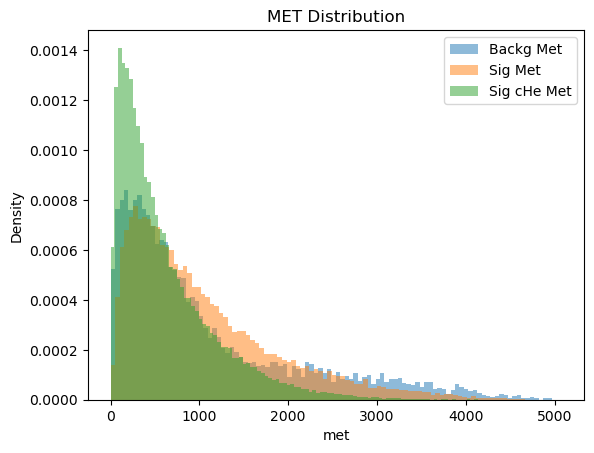

In [73]:
plt.hist(bkgAnni_met,bins = 100,alpha = 0.5,density=True, label = "Backg Met");
plt.hist(sig_met,bins = 100,alpha = 0.5,density=True, label = "Sig Met");
plt.hist(sigcHe_met,bins = 100,alpha = 0.5,density=True, label = "Sig cHe Met");
# plt.hist(bkgVBFcharget_met,bins = 100,alpha = 0.5,density=True, label = "Sig Met");
plt.xlabel("met")
plt.ylabel("Density")
plt.title("MET Distribution")
# plt.xlim(0, 100)

plt.legend()  # 👈 This adds the legend box
plt.show()

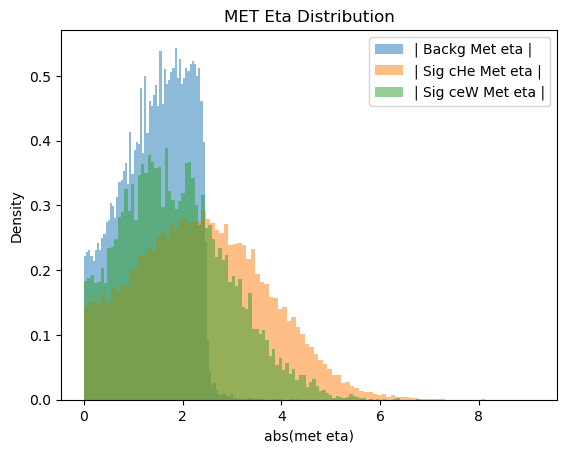

In [6]:
plt.hist(abs(bkg_met_eta),bins = 100,alpha = 0.5,density=True, label = "| Backg Met eta |");
plt.hist(abs(sigcHe_met_eta),bins = 100,alpha = 0.5,density=True, label = "| Sig cHe Met eta |");
plt.hist(abs(sig_met_eta),bins = 100,alpha = 0.5,density=True, label = "| Sig ceW Met eta |");

plt.xlabel("abs(met eta)")
plt.ylabel("Density")
plt.title("MET Eta Distribution")

plt.legend()  # 👈 This adds the legend box
plt.show()

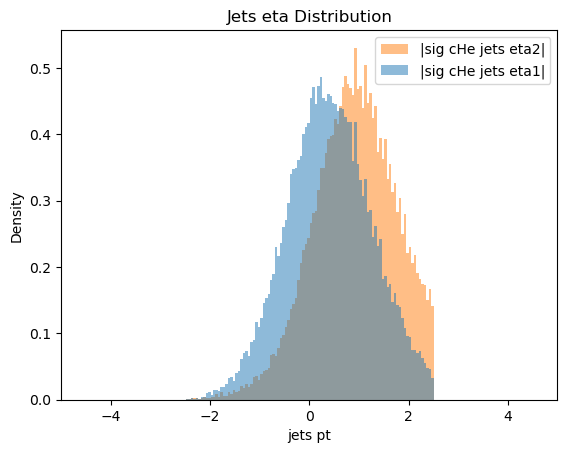

In [30]:
plt.hist(sigcHe_jets_eta,bins = 100,alpha = 0.5,density=True, label = ["|sig cHe jets eta1|", "|sig cHe jets eta2|"]
         , histtype="stepfilled"
        );

plt.xlabel("jets pt")
plt.ylabel("Density")
plt.title("Jets eta Distribution")
plt.xlim(-5, 5)

plt.legend()  # 👈 This adds the legend box
plt.show()

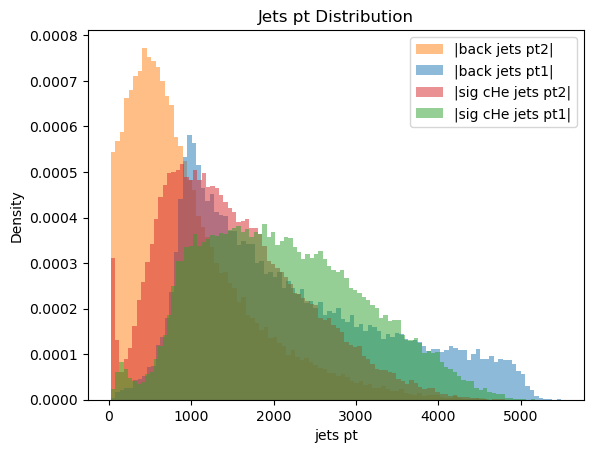

In [7]:
plt.hist(bkg_jets_pt,bins = 100,alpha = 0.5,density=True, label = ["|back jets pt1|", "|back jets pt2|"]
         , histtype="stepfilled"
        );
# plt.hist(bkgVBFneut_jets_pt,bins = 100,alpha = 0.5,density=True, label = ["|neutVBF back jets pt1|", "|neutVBF back jets pt2|"]
#          , histtype="stepfilled"
#         );
# plt.hist(bkgVBFcharge_jets_pt,bins = 100,alpha = 0.5,density=True, label = ["|chargeVBF back jets pt1|", "|chargeVBF back jets pt2|"]
#          , histtype="stepfilled"
#         );
# plt.hist(sig_jets_pt,bins = 100,alpha = 0.5,density=True, label = ["|sig jets pt1|", "|sig jets pt2|"]
#          , histtype="stepfilled"
#         );

plt.hist(sigcHe_jets_pt,bins = 100,alpha = 0.5,density=True, label = ["|sig cHe jets pt1|", "|sig cHe jets pt2|"]
         , histtype="stepfilled"
        );

plt.xlabel("jets pt")
plt.ylabel("Density")
plt.title("Jets pt Distribution")
# plt.xlim(0, 1000)

plt.legend()  # 👈 This adds the legend box
plt.show()

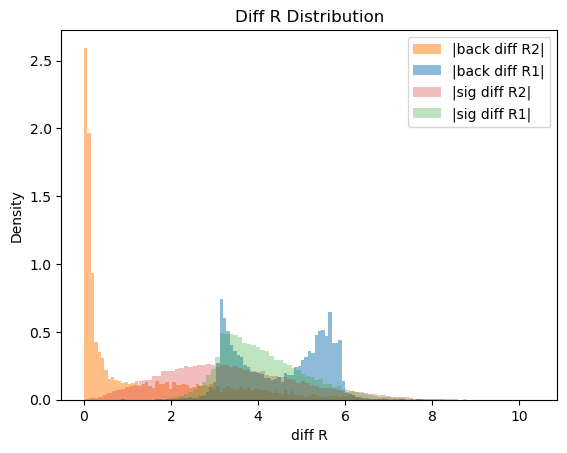

In [77]:
plt.hist(bkgAnni_R,bins = 100,alpha = 0.5,density=True, label = ["|back diff R1|", "|back diff R2|"]
         , histtype="stepfilled"
        );

# plt.hist(bkgVBFcharge_R,bins = 100,alpha = 0.5,density=True, label = ["|back diff R1|", "|back diff R2|"]
#          , histtype="stepfilled"
#         );

plt.hist(sig_R,bins = 100,alpha = 0.3,density=True, label = ["|sig diff R1|", "|sig diff R2|"]
         , histtype="stepfilled"
        );

plt.xlabel("diff R")
plt.ylabel("Density")
plt.title("Diff R Distribution")
# plt.xlim(1, 3)

plt.legend()  # 👈 This adds the legend box
plt.show()

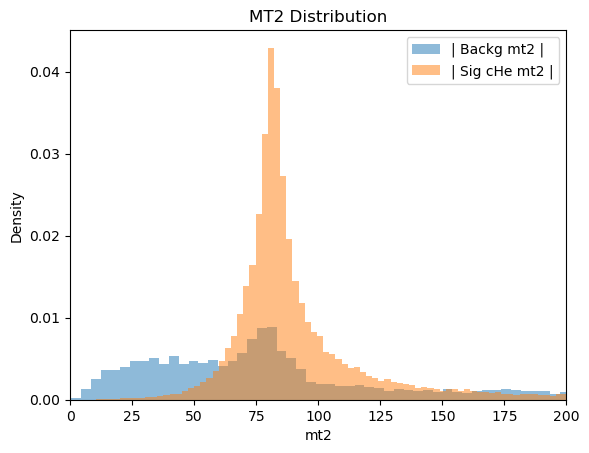

In [74]:
plt.hist(bkgAnni_mt2,bins = 1000,alpha = 0.5,density=True, label = "| Backg mt2 |");
# plt.hist(bkgVBFneut_mt2,bins = 300,alpha = 0.5,density=True, label = "|neutVBF Backg mt2 |");
# plt.hist(sig_mt2,bins = 1000,alpha = 0.5,density=True, label = "| Sig ceW mt2 |");
plt.hist(sigcHe_mt2,bins = 1000,alpha = 0.5,density=True, label = "| Sig cHe mt2 |");

plt.xlabel("mt2")
plt.ylabel("Density")
plt.title("MT2 Distribution")
plt.xlim(0, 200)

plt.legend()  # 👈 This adds the legend box
plt.show()

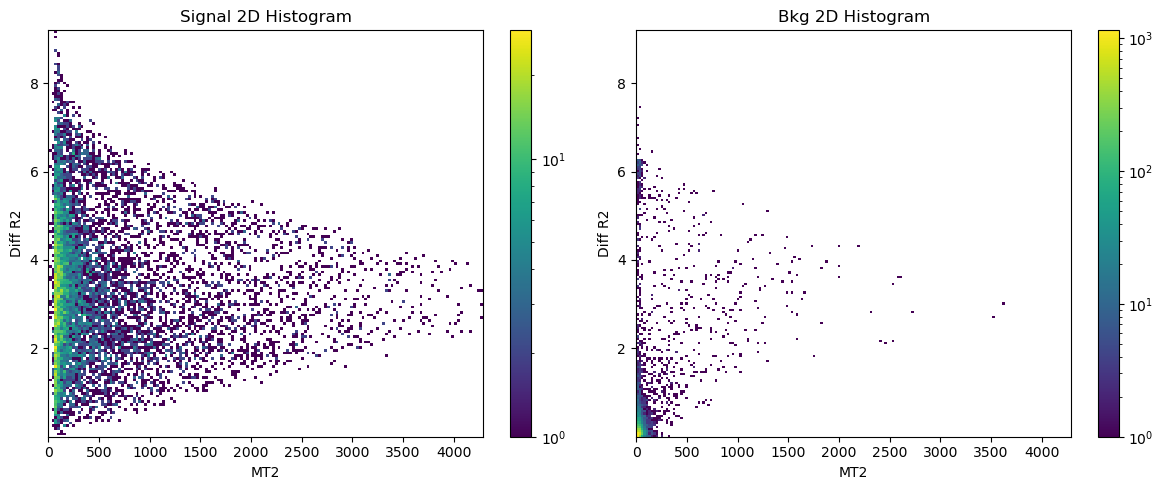

In [173]:
# Convert to NumPy
sig_mt2_np = ak.to_numpy(sig_mt2[:,0])
sig_diffR2_np = ak.to_numpy(sig_R[:,1])

bkg_mt2_np = ak.to_numpy(bkg_mt2[:,0])
bkg_diffR2_np = ak.to_numpy(bkg_R[:,1])

# Create figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First 2D histogram
p1 = ax1.hist2d(sig_mt2_np, sig_diffR2_np, bins=150
                # , density=True
                , cmap='viridis'
           , norm='log'
          )
ax1.set_title("Signal 2D Histogram")
ax1.set_xlabel("MT2")
ax1.set_ylabel("Diff R2")
fig.colorbar(p1[3], ax=ax1)

# Second 2D histogram
p2 = ax2.hist2d(bkg_mt2_np, bkg_diffR2_np, bins=150
                # , density=True
                , cmap='viridis'
           , norm='log'
               )
ax2.set_title("Bkg 2D Histogram")
ax2.set_xlabel("MT2")
ax2.set_ylabel("Diff R2")
fig.colorbar(p2[3], ax=ax2)

#### data range ####

xmin = min(np.min(sig_mt2_np), np.min(bkg_mt2_np))
xmax = max(np.max(sig_mt2_np), np.max(bkg_mt2_np))
ymin = min(np.min(sig_diffR2_np), np.min(bkg_diffR2_np))
ymax = max(np.max(sig_diffR2_np), np.max(bkg_diffR2_np))

ax1.set_xlim(xmin, xmax)
ax2.set_xlim(xmin, xmax)
ax1.set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

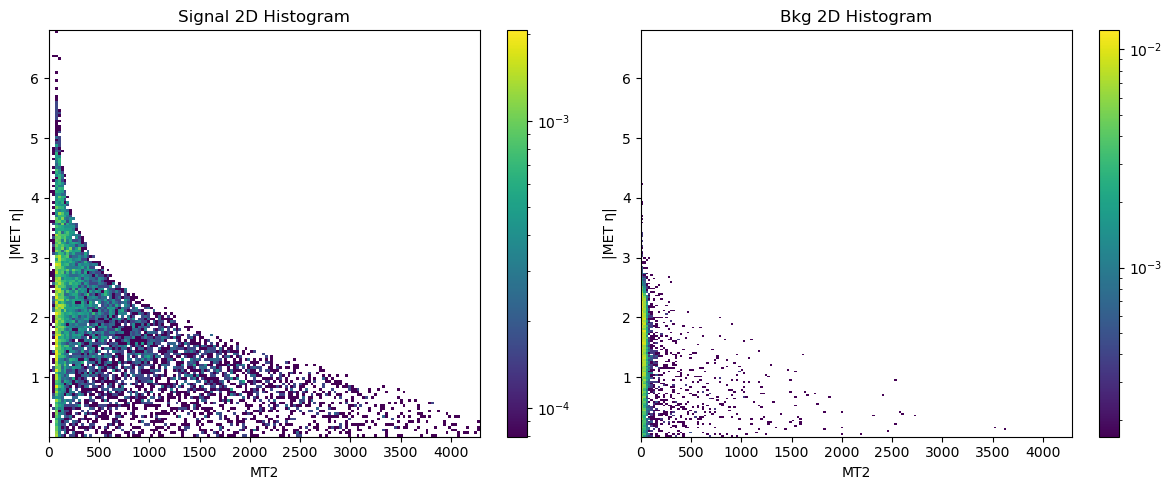

In [164]:
# Convert to NumPy
sig_mt2_np = ak.to_numpy(sig_mt2[:,0])
sig_met_eta_np = ak.to_numpy(abs(sig_met_eta[:,0]))

bkg_mt2_np = ak.to_numpy(bkg_mt2[:,0])
bkg_met_eta_np = ak.to_numpy(abs(bkg_met_eta[:,0]))

# Create figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First 2D histogram
p1 = ax1.hist2d(sig_mt2_np, sig_met_eta_np, bins=150
                # , density=True
                , cmap='viridis'
           , norm='log'
          )
ax1.set_title("Signal 2D Histogram")
ax1.set_xlabel("MT2")
ax1.set_ylabel("|MET η|")
fig.colorbar(p1[3], ax=ax1)

# Second 2D histogram
p2 = ax2.hist2d(bkg_mt2_np, bkg_met_eta_np, bins=150
                # , density=True
                , cmap='viridis'
           , norm='log'
               )
ax2.set_title("Bkg 2D Histogram")
ax2.set_xlabel("MT2")
ax2.set_ylabel("|MET η|")
fig.colorbar(p2[3], ax=ax2)

#### data range ####

xmin = min(np.min(sig_mt2_np), np.min(bkg_mt2_np))
xmax = max(np.max(sig_mt2_np), np.max(bkg_mt2_np))
ymin = min(np.min(sig_met_eta_np), np.min(bkg_met_eta_np))
ymax = max(np.max(sig_met_eta_np), np.max(bkg_met_eta_np))

ax1.set_xlim(xmin, xmax)
ax2.set_xlim(xmin, xmax)
ax1.set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

In [20]:
def read_cross_and_events(file_path):
    with open(file_path, "r") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue  # skip header or empty lines
            parts = line.strip().split()
            cross = float(parts[2])
            nb_event = int(parts[4])
            return cross
    raise ValueError("No valid data line found in the file.")

sig_xsec = read_cross_and_events("outputs/mNPceW_muW_taW_NOEVA.txt")
# back_xsec_NOEVA = read_cross_and_events("outputs/NPceW_mumu_taWnut_bckg.txt")
back_xsec_VBFneut = read_cross_and_events("outputs/NPceW_mumu_taWnut_neutVBF_bckg.txt")
back_xsec_VBFcharge = read_cross_and_events("outputs/NPceW_mumu_taWnut_chargedVBF_bckg.txt")
back_xsec_anni = read_cross_and_events("outputs/NPceW_mumu_taWnut_annihi_bckg.txt")
sig_xsec_cHL3 = read_cross_and_events("outputs/NPcHL3_muW_taW_NOEVA.txt")
sig_xsec_cHL1 = read_cross_and_events("outputs/NPcHL1_muW_taW_NOEVA.txt")
sig_xsec_cHe = read_cross_and_events("outputs/NPcHe_muW_taW_NOEVA.txt")


# "parton_level_csx/muw_taw-che.txt" 20L, 748B                  1,1           All
#   === Results Summary for run: run_01 tag: tag_1  process: MADGRAPH ===
#      Cross-section :   0.0001053 +- 1.701e-07 pb
#      Nb of events :  50000
#   === Results Summary for run: run_02 tag: tag_1  process: MADGRAPH ===
#      Cross-section :   0.0001053 +- 1.721e-07 pb
#      Nb of events :  50000
#   === Results Summary for run: run_03 tag: tag_1  process: MADGRAPH ===
#      Cross-section :   0.0001052 +- 1.774e-07 pb
#      Nb of events :  50000
#   === Results Summary for run: run_04 tag: tag_1  process: MADGRAPH ===
#      Cross-section :   0.000105 +- 9.607e-08 pb
#      Nb of events :  50000
#   === Results Summary for run: run_05 tag: tag_1  process: MADGRAPH ===
#      Cross-section :   0.000105 +- 1.558e-07 pb
#      Nb of events :  50000
sig_xsec_cHe = 0.000105
sig_nbEvents = sigcHe_num


print(bkgAnni_num)
print(bkg_num)

32115
50000


In [8]:
print("back charged:",back_xsec_VBFcharge*0.6479*0.8*10**7)
print("back neutral:", back_xsec_VBFneut*0.6479*0.8*10**7)
print("back anni:", back_xsec_anni*0.6479*0.8*10**7)
print("back NOEVA:", back_xsec_NOEVA*0.6479*0.8*10**7)
print("Sig ceW:", sig_xsec*0.6741*0.6479*0.8*10**7)

print("back charged:",back_xsec_VBFcharge)
print("back neutral:", back_xsec_VBFneut)
print("back anni:", back_xsec_anni)
print("back NOEVA:", back_xsec_NOEVA)
print("Sig ceW:", sig_xsec)

# neut: 250000 , 142893
# charged: 205343 , 64702
print(back_xsec_anni)

back charged: 40305.939666430764
back neutral: 3493.7678817738406
back anni: 966.060987584
back NOEVA: 8007.678584400001
Sig ceW: 3095.1941093892233
back charged: 0.007776265563055787
back neutral: 0.0006740561587000001
back anni: 0.00018638312
back NOEVA: 0.0015449295
Sig ceW: 0.0008858610281600001
0.00018638312


In [62]:
#Hengameh Imposing cuts
    
min_cut_eta = -100 #0.55 min is optimal with no other cuts, but not helpful with E and pt cuts
max_cut_eta = 100 #not helpful with E and pt cuts

############
############
############
# min_cut_R2 = 1 # 3 is optimal with no other cuts, not helpful with E and pt cuts

# jetspt2_lowcut = 500 #3200
# jetspt1_lowcut = 600 #3200

# min_met = 20 #100 Optimal with no other cuts, not helpful with E and pt cuts already imposed
# max_mt2 = 80

########### Signal Decay rate signal multiplication 0.6741, 0.6479
########### Signal Decay rate signal multiplication 0.6741
########### Divide by original number of madgrapg events
# signal: multiply by 0.6741*0.6479*0.8
# bkg: multiply by 0.6479*0.8

# I leave postfix empty: sig is an example of what i feed
# Sample name is for printing purposes

def impose_all_cuts(xs, prefix, postfix, Sample_name, min_cut_R2=1.7,jetspt1_lowcut=1500,jetspt2_lowcut=500, min_met=50, max_mt2=50, met_eta_lower=2):
    num_events = globals()[prefix + "_num"]
    
    (num_eta1,num_eta2, eta_cut) = impose_eta_cut(prefix, postfix, min_cut_eta, max_cut_eta)

    R1_np = ak.to_numpy(globals()[prefix + "_R"][:,0])
    R2_np = ak.to_numpy(globals()[prefix + "_R"][:,1])
    
    (num_R2, R2_cut) = impose_lower_cut_arr(R2_np, min_cut_R2)
    
    # (num_R1,num_R2, R_cut) = impose_lower_cut_2D(prefix + "_R" + postfix, min_cut_R)
    
    (num_met, met_cut) = impose_lower_cut(prefix + "_met" + postfix, min_met)
    (num_mt2, mt2_cut) = impose_lower_cut(prefix + "_mt2" + postfix, max_mt2)
    (num_met_eta, met_eta_cut) = impose_lower_cut_abs(prefix + "_met_eta" + postfix, met_eta_lower)

    # (num_jets1,num_jets2, jet_cut) = impose_lower_cut_2D(prefix + "_jets_pt" + postfix, jetpt_lowcut)

    pt1_np = ak.to_numpy(globals()[prefix + "_jets_pt"][:,0])
    pt2_np = ak.to_numpy(globals()[prefix + "_jets_pt"][:,1])
    
    (num_jetspt1, jetspt1_cut) = impose_lower_cut_arr(pt1_np, jetspt1_lowcut)
    (num_jetspt2, jetspt2_cut) = impose_lower_cut_arr(pt2_np, jetspt2_lowcut)
    
    num_All = ak.sum(eta_cut[:,0] & eta_cut[:,1] & R2_cut & met_cut& mt2_cut & jetspt1_cut & jetspt2_cut & met_eta_cut)
    
    cut_nums = [num_eta1, num_eta2, num_R2, num_met, num_mt2, num_jetspt1, num_jetspt2, num_met_eta
                , num_All
               ]
    
    cut_names = ["Delta eta1","Delta eta2", "Delta R2", "met", "mt2",\
                 "Jets_pt1", "Jets_pt2", "met_eta"
                 , "All"
                ]
    
    array_with_cuts = np.array([xs*cut_num/num_events*10*10**6 for cut_num in cut_nums])
    Sample_name = Sample_name + " Cuts"

    if(DO_PRINT): 
        print()  # blank line before
        print(Sample_name)
        print(f"OG MadGraph #Events: {num_events}")
        
        for name, num, val in zip(cut_names, cut_nums, array_with_cuts):
            print(f"{name}: {num}, {val:.8f}")
        
        print()  # final spacing
    return array_with_cuts, cut_names

    # print("Num Events", num_events, end=", ")
    # for (name, num) in zip(cut_names, cut_nums):
    #     print(name, num, end=", ")
    # print("\n")
    # return (array_with_cuts, cut_names)

In [63]:
#Hengameh Imposing cuts
    
min_cut_eta = -100 #0.55 min is optimal with no other cuts, but not helpful with E and pt cuts
max_cut_eta = 100 #not helpful with E and pt cuts

############
############
############
# min_cut_R2 = 1 # 3 is optimal with no other cuts, not helpful with E and pt cuts

# jetspt2_lowcut = 500 #3200
# jetspt1_lowcut = 600 #3200

# min_met = 20 #100 Optimal with no other cuts, not helpful with E and pt cuts already imposed
# max_mt2 = 80

########### Signal Decay rate signal multiplication 0.6741, 0.6479
########### Signal Decay rate signal multiplication 0.6741
########### Divide by original number of madgrapg events
# signal: multiply by 0.6741*0.6479*0.8
# bkg: multiply by 0.6479*0.8

# I leave postfix empty: sig is an example of what i feed
# Sample name is for printing purposes

def impose_all_cuts_opt(xs, prefix, postfix, Sample_name, min_cut_R2=1.7,jetspt1_lowcut=1500,jetspt2_lowcut=500, min_met=50, max_mt2=50, met_eta_lower=2):
    num_events = globals()[prefix + "_num"]
    
    (num_eta1,num_eta2, eta_cut) = impose_eta_cut(prefix, postfix, min_cut_eta, max_cut_eta)

    R2_np = ak.to_numpy(globals()[prefix + "_R"][:,1])
    
    (num_R2, R2_cut) = impose_lower_cut_arr(R2_np, min_cut_R2)
    
    # (num_R1,num_R2, R_cut) = impose_lower_cut_2D(prefix + "_R" + postfix, min_cut_R)
    
    (num_met, met_cut) = impose_lower_cut(prefix + "_met" + postfix, min_met)
    (num_mt2, mt2_cut) = impose_lower_cut(prefix + "_mt2" + postfix, max_mt2)
    (num_met_eta, met_eta_cut) = impose_lower_cut_abs(prefix + "_met_eta" + postfix, met_eta_lower)

    # (num_jets1,num_jets2, jet_cut) = impose_lower_cut_2D(prefix + "_jets_pt" + postfix, jetpt_lowcut)

    pt1_np = ak.to_numpy(globals()[prefix + "_jets_pt"][:,0])
    pt2_np = ak.to_numpy(globals()[prefix + "_jets_pt"][:,1])
    
    (num_jetspt1, jetspt1_cut) = impose_lower_cut_arr(pt1_np, jetspt1_lowcut)
    (num_jetspt2, jetspt2_cut) = impose_lower_cut_arr(pt2_np, jetspt2_lowcut)
    
    num_All = ak.sum(eta_cut[:,0] & eta_cut[:,1] & R2_cut & met_cut& mt2_cut & jetspt1_cut & jetspt2_cut & met_eta_cut)

    return xs*num_All/num_events*10**7
    

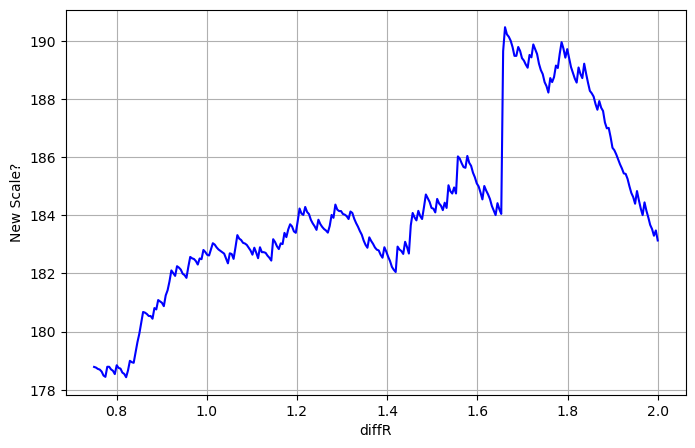

In [40]:
# Create an array of x values from 1 to 3
DO_PRINT = False

R_values = np.linspace(0.75, 2, 300)

# Evaluate the function for all x values

# Create an empty list for y values
y_values = []

# Use a for loop to fill y_values
for x in R_values:

    sigarray, signames = impose_all_cuts(0.6741*0.6479*0.8*sig_xsec, 'sig', '', 'Signal ceW muWtauW', x)
    NOEVA_bckg, signames = impose_all_cuts(0.6479*0.8*back_xsec_NOEVA, 'bkg', '', 'Backg ceW muWtauW', x)
    VBFneut_bckg, signames = impose_all_cuts(0.6479*0.8*back_xsec_VBFneut, 'bkgVBFneut', '', 'Backg VBF Neut ceW muWtauW', x)
    VBFcharge_bckg, signames = impose_all_cuts(0.6479*0.8*back_xsec_VBFcharge, 'bkgVBFcharge', '', 'Backg VBF Charge ceW muWtauW', x)
    VBFanni_bckg, signames = impose_all_cuts(0.6479*0.8*back_xsec_anni, 'bkgAnni', '', 'Backg Anni ceW muWtauW', x)

    y_values.append(sigarray[-1]/np.sqrt(NOEVA_bckg[-1]+VBFneut_bckg[-1]+VBFcharge_bckg[-1]+VBFanni_bckg[-1]))
    
# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(R_values, y_values, label='f(x)', color='blue')
plt.xlabel('diffR')
plt.ylabel('New Scale?')
plt.grid(True)
plt.show()

In [11]:
print(sig_xsec, sig_xsec_cHe)
print(sig_xsec_cHe)

0.0008858610281600001 0.000105
0.000105


In [70]:
DO_PRINT = True
# 1.7, 700, 550, 30, 80, 2.2
# min_cut_R2=1.7,jetspt1_lowcut=1500,jetspt2_lowcut=400, min_met=25, max_mt2=50, met_eta_lower=2
# 1.7, 1500,   400,    25,    50,     2
sigarrayceW, sigceWnames = impose_all_cuts(0.6741*0.6479*0.8*sig_xsec, 'sig', '', 'Signal ceW muWtauW', 1.7,1500, 500, 50, 0, 2)
sigarraycHe, sigcHenames = impose_all_cuts(0.6741*0.6479*0.8*sig_xsec_cHe, 'sigcHe', '', 'Signal cHe muWtauW', 1.7,1500, 500, 50, 0, 2)
sigarraycHL3, sigcHL3names = impose_all_cuts(0.6741*0.6479*0.8*sig_xsec_cHL3, 'sigcHL3', '', 'Signal cHL3 muWtauW', 1.7,1500, 500, 50, 50, 2)
sigarraycHL1, sigcHL1names = impose_all_cuts(0.6741*0.6479*0.8*sig_xsec_cHL1, 'sigcHL1', '', 'Signal cHL1 muWtauW', 1.7,1500, 500, 50, 50, 2)

# NOEVA_bckg, signames = impose_all_cuts(0.6479*0.8*back_xsec_NOEVA, 'bkg', '', 'Backg ceW muWtauW', 1.7,1500, 400, 25, 50, 2)
VBFneut_bckg, signames = impose_all_cuts(0.6479*0.8*back_xsec_VBFneut, 'bkgVBFneut', '', 'Backg VBF Neut ceW muWtauW', 1.7,1500, 500, 50, 50, 2)
VBFcharge_bckg, signames = impose_all_cuts(0.6479*0.8*back_xsec_VBFcharge, 'bkgVBFcharge', '', 'Backg VBF Charge ceW muWtauW', 1.7,1500, 500, 50, 50, 2)
VBFanni_bckg, signames = impose_all_cuts(0.6479*0.8*back_xsec_anni, 'bkgAnni', '', 'Backg Anni ceW muWtauW', 1.7,1500, 500, 50, 50, 2)

print(sigarrayceW[-1]/np.sqrt(NOEVA_bckg[-1]+VBFneut_bckg[-1]+VBFcharge_bckg[-1]+VBFanni_bckg[-1]))
print(sigarraycHe[-1]/np.sqrt(NOEVA_bckg[-1]+VBFneut_bckg[-1]+VBFcharge_bckg[-1]+VBFanni_bckg[-1]))

2121/10000
3275
2334
2432
2
0
20



Signal ceW muWtauW Cuts
OG MadGraph #Events: 50000
Delta eta1: 44907, 2776.75274059
Delta eta2: 44907, 2776.75274059
Delta R2: 38884, 2404.33013929
met: 44625, 2759.31572024
mt2: 44907, 2776.75274059
Jets_pt1: 30460, 1883.44553140
Jets_pt2: 39166, 2421.76715964
met_eta: 18995, 1174.52553739
All: 9542, 590.01435524


Signal cHe muWtauW Cuts
OG MadGraph #Events: 50000
Delta eta1: 45847, 336.39730796
Delta eta2: 45847, 336.39730796
Delta R2: 37336, 273.94878378
met: 44263, 324.77488259
mt2: 45847, 336.39730796
Jets_pt1: 31726, 232.78602727
Jets_pt2: 41770, 306.48276994
met_eta: 27124, 199.01935963
All: 14814, 108.69609179


Signal cHL3 muWtauW Cuts
OG MadGraph #Events: 10000
Delta eta1: 9909, 324.22581068
Delta eta2: 9909, 324.22581068
Delta R2: 7446, 243.63562280
met: 9649, 315.71852328
mt2: 9711, 317.74718412
Jets_pt1: 6900, 225.77031927
Jets_pt2: 8367, 273.77105237
met_eta: 4679, 153.09845274
All: 2334, 76.36926452


Signal cHL1 muWtauW Cuts
OG MadGraph #Events: 10000
Delta eta1: 9909

20

In [30]:
# min_cut_R2=1,jetspt1_lowc=600,jetspt2_lowcut=500, min_met=20, max_mt2=80

def minimizer_func(x):
    
    # sigarray, signames = impose_all_cuts(0.6741*0.6479*0.8*sig_xsec, 'sig', '', 'Signal ceW muWtauW', x[0], x[1], x[2], x[3], x[4])
    sigarray = impose_all_cuts_opt(0.6741*0.6479*0.8*sig_xsec_cHe, 'sigcHe', '', 'Signal cHe muWtauW', x[0], x[1], x[2], x[3], x[4], x[5])
    NOEVA_bckg = impose_all_cuts_opt(0.6479*0.8*back_xsec_NOEVA, 'bkg', '', 'Backg ceW muWtauW', x[0], x[1], x[2], x[3], x[4])
    VBFneut_bckg = impose_all_cuts_opt(0.6479*0.8*back_xsec_VBFneut, 'bkgVBFneut', '', 'Backg VBF Neut ceW muWtauW', x[0], x[1], x[2], x[3], x[4], x[5])
    VBFcharge_bckg = impose_all_cuts_opt(0.6479*0.8*back_xsec_VBFcharge, 'bkgVBFcharge', '', 'Backg VBF Charge ceW muWtauW', x[0], x[1], x[2], x[3], x[4], x[5])
    VBFanni_bckg = impose_all_cuts_opt(0.6479*0.8*back_xsec_anni, 'bkgAnni', '', 'Backg Anni ceW muWtauW', x[0], x[1], x[2], x[3], x[4], x[5])

    return -sigarray/np.sqrt(NOEVA_bckg+VBFneut_bckg+VBFcharge_bckg+VBFanni_bckg)
    

In [12]:
%time minimizer_func([ 1.6 ,1500, 400, 10, 50, 2.2])

CPU times: user 49.6 ms, sys: 16.2 ms, total: 65.7 ms
Wall time: 62.9 ms


-42.234038575765396

In [31]:
# example usage
DO_PRINT = False

# def brute_minimize(f, ranges):
#     """
#     Brute-force minimization of f over a grid defined by ranges.
    
#     Parameters:
#       f: function that takes a 1D numpy array x and returns a scalar.
#       ranges: list of slice(start, stop, step) objects defining each dimension.
    
#     Returns:
#       x_min: numpy array at which f(x) is minimal.
#       f_min: minimal function value.
#     """
#     # Create grid for each dimension
#     grids = [np.arange(r.start, r.stop, r.step) for r in ranges]
#     # Form a meshgrid and flatten into a list of points
#     mesh = np.meshgrid(*grids, indexing='ij')
#     points = np.stack([m.flatten() for m in mesh], axis=-1)
#     # Evaluate f on each point
#     values = np.apply_along_axis(f, 1, points)
#     # Find minimum
#     idx = np.argmin(values)
#     return points[idx], values[idx]

import itertools

def brute_minimize(f, ranges):
    """
    Brute‐force minimization skipping non‐finite values (e.g., -inf).
    """
    x_min = None
    f_min = None
    for pt in itertools.product(*[np.arange(r.start, r.stop, r.step) for r in ranges]):
        x = np.array(pt)
        val = f(x)
        if not np.isfinite(val):
            continue
        if f_min is None or val < f_min:
            f_min = val
            x_min = x
    return x_min, f_min

In [32]:
ranges = [slice(0.2, 1.8, 0.1), slice(1500, 1700,100),slice(400, 700,100), slice(10, 30,5), slice(50, 90,5),slice(2, 4,0.1)]  # 6D search
x_min, f_min = brute_minimize(minimizer_func, ranges)
print("Minimum at:", x_min, "with value:", f_min)

Minimum at: [   1.7 1500.   400.    25.    50.     2. ] with value: -51.60351739630506


In [44]:
print(x_values)

[0.00000000e+00 1.00033344e+00 2.00066689e+00 ... 2.99799933e+03
 2.99899967e+03 3.00000000e+03]


In [34]:
minimizer_func([1.7, 1500,   500,    50,    50,     2])

-53.07499180224662

In [20]:
# Create an array of x values from 1 to 3
DO_PRINT = False

x_values = np.linspace(0, 10, 3000)

# Evaluate the function for all x values

# Create an empty list for y values
y_values = []

# Use a for loop to fill y_values
# (xs, prefix, postfix, Sample_name, min_cut_R2=1,jetspt1_lowcut=600,jetspt2_lowcut=500, min_met=20, max_mt2=80, met_eta_lower=2)

# impose_all_cuts_opt(0.6741*0.6479*0.8*sig_xsec_cHe, 'sigcHe', '', 'Signal cHe muWtauW', x[0], x[1], x[2], x[3], x[4], x[5])

 # 1.6 1500.   400.    10.    50.     2.2
# 1.7 1500.   400.    25.    50.     2.
for x in x_values:

    sigarray, signames = impose_all_cuts(0.6741*0.6479*0.8*sig_xsec_cHe, 'sig', '', 'Signal cHe muWtauW', 
                                         min_cut_R2=1.7,jetspt1_lowcut=1500,jetspt2_lowcut=400, min_met=25, max_mt2=50, met_eta_lower=x)
    NOEVA_bckg, signames = impose_all_cuts(0.6479*0.8*back_xsec_NOEVA, 'bkg', '', 'Backg ceW muWtauW', 
                                          min_cut_R2=1.7,jetspt1_lowcut=1500,jetspt2_lowcut=400, min_met=25, max_mt2=50, met_eta_lower=x)
    VBFneut_bckg, signames = impose_all_cuts(0.6479*0.8*back_xsec_VBFneut, 'bkgVBFneut', '', 'Backg VBF Neut ceW muWtauW', 
                                             min_cut_R2=1.7,jetspt1_lowcut=1500,jetspt2_lowcut=400, min_met=25, max_mt2=50, met_eta_lower=x)
    VBFcharge_bckg, signames = impose_all_cuts(0.6479*0.8*back_xsec_VBFcharge, 'bkgVBFcharge', '', 'Backg VBF Charge ceW muWtauW', 
                                               min_cut_R2=1.7,jetspt1_lowcut=1500,jetspt2_lowcut=400, min_met=25, max_mt2=50, met_eta_lower=x)
    VBFanni_bckg, signames = impose_all_cuts(0.6479*0.8*back_xsec_anni, 'bkgAnni', '', 'Backg Anni ceW muWtauW', 
                                             min_cut_R2=1.7,jetspt1_lowcut=1500,jetspt2_lowcut=400, min_met=25, max_mt2=50, met_eta_lower=x)

    y_values.append(sigarray[-1]/np.sqrt(NOEVA_bckg[-1]+VBFneut_bckg[-1]+VBFcharge_bckg[-1]+VBFanni_bckg[-1]))


/var/folders/l2/0n4dnq756ddf3nzsrhqvwh200000gn/T/ipykernel_72655/2801970127.py:31: RuntimeWarning: divide by zero encountered in scalar divide
  y_values.append(sigarray[-1]/np.sqrt(NOEVA_bckg[-1]+VBFneut_bckg[-1]+VBFcharge_bckg[-1]+VBFanni_bckg[-1]))
/var/folders/l2/0n4dnq756ddf3nzsrhqvwh200000gn/T/ipykernel_72655/2801970127.py:31: RuntimeWarning: invalid value encountered in scalar divide
  y_values.append(sigarray[-1]/np.sqrt(NOEVA_bckg[-1]+VBFneut_bckg[-1]+VBFcharge_bckg[-1]+VBFanni_bckg[-1]))


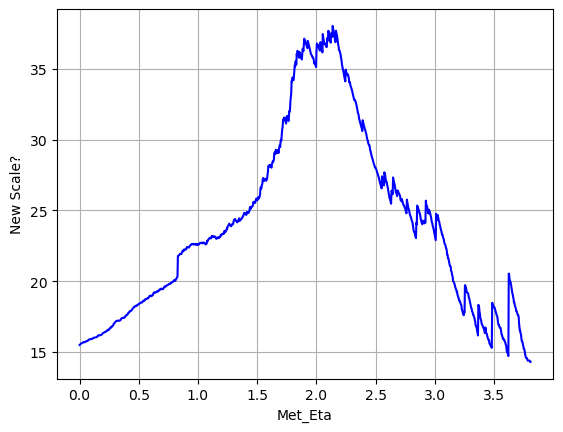

In [21]:
# Plot the results
# plt.figure(figsize=(8, 5))
plt.plot(x_values, y_values, label='f(x)', color='blue')
plt.xlabel('Met_Eta')
plt.ylabel('New Scale?')
plt.grid(True)
plt.savefig('Met_Eta.pdf', format='pdf')
plt.show()

In [22]:
# DO_PRINT = False
# Define bounds for the variables (optional)
# min_cut_R2, jetspt1_lowcut, jetspt2_lowcut, min_met, max_mt2, met_eta
#CeW
# bounds = [(1, 2), (500, 700), (400,600 ),(10,30) , (70,90)]

rranges = (slice(0.2, 1.8, 0.1), slice(1500, 1700,100),slice(400, 700,100), slice(10, 30,5), slice(50, 90,10),slice(2, 4,0.1))

resbrute = brute(minimizer_func, rranges, full_output=0)
resbrute[0]  # global minimum
resbrute[1]  # function value at global minimum

/var/folders/l2/0n4dnq756ddf3nzsrhqvwh200000gn/T/ipykernel_37974/3573965642.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  return -sigarray/np.sqrt(NOEVA_bckg+VBFneut_bckg+VBFcharge_bckg+VBFanni_bckg)


KeyboardInterrupt: 

In [26]:
# Initial guess for the solution: min_cut_R2=1,jetspt1_lowc=600,jetspt2_lowcut=500, min_met=20, max_mt2=80
DO_PRINT = False
from scipy.optimize import differential_evolution

# min_cut_R2, jetspt1_lowcut, jetspt2_lowcut, min_met, max_mt2
x0 = np.array([1, 600,500,20, 80])

# Define bounds for the variables (optional)
# min_cut_R2, jetspt1_lowcut, jetspt2_lowcut, min_met, max_mt2, met_eta
#CeW
# bounds = [(1, 2), (500, 700), (400,600 ),(10,30) , (70,90)]
bounds = [(1, 2), (500, 1700), (500,700 ),(10,30) , (50,70), ()]

# Define constraints (optional)
constraints = ()

# # Minimize the function
# result = minimize(minimizer_func, x0, method='L-BFGS-B', bounds=bounds, constraints=constraints)

# # Print the results
# if result.success:
#   print("Minimum found:")
#   print("x =", result.x)
#   print("f(x) =", result.fun)
# else:
#   print("Optimization failed:")
#   print(result.message)

result = differential_evolution(
    minimizer_func,
    bounds,
    strategy='best1bin',
    maxiter=500,        # increase for more thorough search
    popsize=15,         # larger => more diverse population
    tol=1e-6,
    polish=True         # run a final local polish (L-BFGS-B) on the best candidate
)

print("Solution:", result.x)
print("Cost    :", result.fun)

# min_cut_R2, jetspt1_lowcut, jetspt2_lowcut, min_met, max_mt2
# ceW
# 1.7, 700, 550, 30, 80
#cHe
# 1.7, 600, 600, 15, 80

Solution: [  1.79912007 631.01890935 589.9098984   14.29546671  70.00071732]
Cost    : -21.816050834937208


In [ ]:
# ceW
# # 1.7, 700, 550, 30, 80
# Solution: [  1.78545393 697.24440777 552.23639707  25.97674937  70.55164363]
# Cost    : -217.2641907995478

In [169]:
# bkgAnni_mt2, bkgVBFcharge_mt2, bkgVBFneut_mt2
sigarray, signames = impose_all_cuts(0.6741*0.6479*0.8*sig_xsec, 'sig', '', 'Signal ceW muWtauW')
NOEVA_bckg, signames = impose_all_cuts(0.6479*0.8*back_xsec_NOEVA, 'bkg', '', 'Backg ceW muWtauW')
VBFneut_bckg, signames = impose_all_cuts(0.6479*0.8*back_xsec_VBFneut, 'bkgVBFneut', '', 'Backg VBF Neut ceW muWtauW')
VBFcharge_bckg, signames = impose_all_cuts(0.6479*0.8*back_xsec_VBFcharge, 'bkgVBFcharge', '', 'Backg VBF Charge ceW muWtauW')
VBFanni_bckg, signames = impose_all_cuts(0.6479*0.8*back_xsec_anni, 'bkgAnni', '', 'Backg Anni ceW muWtauW')

print(sigarray[-1]/np.sqrt(NOEVA_bckg[-1]+VBFneut_bckg[-1]+VBFcharge_bckg[-1]+VBFanni_bckg[-1]))

# New_scale = 10/np.sqrt(((2*bkg_tot_mumu)**(1/4))/25.1487/np.sqrt(2*sig_xs))


Signal ceW muWtauW Cuts
OG MadGraph #Events: 10000
Delta eta1: 9718, 3007.90963550
Delta eta2: 9718, 3007.90963550
Delta R2: 9283, 2873.26869175
met: 9713, 3006.36203845
mt2: 8991, 2782.88902375
Jets_pt1: 9563, 2959.93412681
Jets_pt2: 8639, 2673.93819110
All: 7682, 2377.72811483


Backg ceW muWtauW Cuts
OG MadGraph #Events: 10000
Delta eta1: 8683, 7039.62232631
Delta eta2: 8683, 7039.62232631
Delta R2: 827, 670.47882804
met: 8560, 6939.90177510
mt2: 791, 641.29232525
Jets_pt1: 6651, 5392.20639091
Jets_pt2: 3289, 2666.51132457
All: 117, 94.85613408


Backg VBF Neut ceW muWtauW Cuts
OG MadGraph #Events: 50000
Delta eta1: 14155, 31396.67117410
Delta eta2: 14155, 31396.67117410
Delta R2: 13227, 29338.30940444
met: 12385, 27470.70098843
mt2: 3828, 8490.74229986
Jets_pt1: 92, 204.06172716
Jets_pt2: 11, 24.39868477
All: 2, 4.43612450


Backg VBF Charge ceW muWtauW Cuts
OG MadGraph #Events: 4903
Delta eta1: 1602, 13169.51159405
Delta eta2: 1602, 13169.51159405
Delta R2: 1530, 12577.62343252
m

In [17]:
min_cut_eta = -5 #0.55 min is optimal with no other cuts, but not helpful with E and pt cuts
max_cut_eta = 5 #not helpful with E and pt cuts
min_cut_R = 0 # 3 is optimal with no other cuts, not helpful with E and pt cuts
muon_pt_cut = 3200 #3200
muon_E_cut = 4900 #4900
min_met = 0 #100 Optimal with no other cuts, not helpful with E and pt cuts already imposed
max_mt2 = 50


def impose_all_cuts(xs, prefix, postfix, Sample_name):
    num_events = globals()[prefix + "_num" + postfix]
    (num_eta, eta_cut) = impose_eta_cut(prefix, postfix, min_cut_eta, max_cut_eta)
    (num_R, R_cut) = impose_lower_cut(prefix + "_R" + postfix, min_cut_R)
    (num_met, met_cut) = impose_lower_cut(prefix + "_met" + postfix, min_met)
    (num_pt, pt_cut) = impose_lower_cut(prefix + "_muons_pt" + postfix, muon_pt_cut)
    (num_E, E_cut) = impose_lower_cut(prefix + "_muons_E" + postfix, muon_E_cut)
    (num_mt2, mt2_cut) = impose_upper_cut(prefix + "_mt2" + postfix, max_mt2)
    
    num_pTE = ak.sum(pt_cut & E_cut)
    num_All = ak.sum(eta_cut & R_cut & met_cut & pt_cut & E_cut & mt2_cut)
    cut_nums = [num_eta, num_R, num_met, num_pt, num_E, num_mt2, num_pTE, num_All]
    cut_names = ["Delta eta", "Delta R", "met", "Muon pt", "Muon E", \
                 "mt2", " Muon pT and E", "All"]
    array_with_cuts = np.array([xs*cut_num/num_events for cut_num in cut_nums])
    Sample_name = Sample_name + " Cuts"
    print(Sample_name, end= ": ")
    print("Num Events", num_events, end=", ")
    for (name, num) in zip(cut_names, cut_nums):
        print(name, num, end=", ")
    print("\n")
    return (array_with_cuts, cut_names)

(sig_xs, sig_cut_names) = impose_all_cuts(1.0129299999999999*t_tag*ttoj_decay, "sig", "", "S: mumu>muta")
(bkg_xs, bkg_cut_names) = impose_all_cuts(0.00104054000037051*ttom_decay*t_tag*ttoj_decay, "bkg", "", "mumu>tata")
(bkg_xs2, bkg_cut_names2) = impose_all_cuts(0.0086335991259087*t_tag*ttoj_decay, "bkg", "2", "mumu>muvmtavt")
(bkg_xsww, bkg_cut_namesww) = impose_all_cuts(0.05892670097476*wtom_decay*wtot_decay*t_tag*ttoj_decay, \
                                              "bkg", "ww", "mumu>ww True")
(bkg_xsww2, bkg_cut_namesww2) = impose_all_cuts(0.05892670097476*j_mistag*wtom_decay*wtoj_decay, \
                                              "bkg", "ww2", "mumu>ww Mistag")
(bkg_xsww3, bkg_cut_namesww3) = impose_all_cuts(0.030682170647439774*j_mistag, "bkg", "ww3", "mumu>muvmjj Mistag")
(bkg_xsBB, bkg_cut_namesBB) = impose_all_cuts(0.007963*ttom_decay*t_tag*ttoj_decay, \
                                              "bkg", "BB", "VV>tata")
(bkg_xsBB2, bkg_cut_namesBB2) = impose_all_cuts(1.063*wtom_decay*wtot_decay*t_tag*ttoj_decay, \
                                              "bkg", "BB2", "VV>ww True")
(bkg_xsBB3, bkg_cut_namesBB3) = impose_all_cuts(1.058*j_mistag*wtom_decay*wtoj_decay, \
                                              "bkg", "BB3", "VV>ww Mistag")
(bkg_xsBB4, bkg_cut_namesBB4) = impose_all_cuts(0.3159*j_mistag, \
                                              "bkg", "BB3", "VV>muvmjj Mistag")
(bkg_xsW, bkg_cut_namesW) = impose_all_cuts(0.0001877*ttom_decay*t_tag*ttoj_decay, \
                                              "bkg", "W", "mumu>ww True")
(bkg_xsW2, bkg_cut_namesW2) = impose_all_cuts(0.4174*wtom_decay*wtot_decay*t_tag*ttoj_decay, \
                                              "bkg", "W", "mumu>ww True")
(bkg_xsW3, bkg_cut_namesW3) = impose_all_cuts(0.4174*j_mistag*wtom_decay*wtoj_decay, \
                                              "bkg", "W", "mumu>ww True")


print("Total mumu Bkg:", end=" ") 
bkg_tot_mumu = (bkg_xs + bkg_xs2 + bkg_xsww + bkg_xsww2 + bkg_xsww3)
for (name, cut) in zip(bkg_cut_names, bkg_tot_mumu*(10**7)):
    print(name, cut, end=", ")
print("\n")

print("Total BB Bkg:", end=" ") 
bkg_tot_BB = (bkg_xsBB + bkg_xsBB2 + bkg_xsBB3 + bkg_xsBB4)
for (name, cut) in zip(bkg_cut_namesBB, bkg_tot_BB*(10**7)):
    print(name, cut, end=", ")
print("\n")

print("Total WW Bkg:", end=" ") 
bkg_tot_W = (bkg_xsW)
for (name, cut) in zip(bkg_cut_namesW, bkg_tot_W*(10**7)):
    print(name, cut, end=", ")
print("\n")

print("Total Signal:", end=" ") 
for (name, cut) in zip(bkg_cut_names, sig_xs*(10**7)):
    print(name, cut, end=", ")
print("\n")

print("New Scales:", end=" ") 
New_scale = 10/np.sqrt(((2*bkg_tot_mumu + 2*bkg_tot_BB + 2*bkg_tot_W)**(1/4))/25.1487/np.sqrt(2*sig_xs)) #2 for charge symmetry
for (name, cut) in zip(bkg_cut_names, New_scale):
    print(name, cut, end=", ")
print("\n")

S: mumu>muta Cuts: Num Events 10000, Delta eta 9872, Delta R 9875, met 9875, Muon pt 6992, Muon E 6677, mt2 9652,  Muon pT and E 4706, All 4627, 

mumu>tata Cuts: Num Events 1000000, Delta eta 828507, Delta R 828636, met 828636, Muon pt 54995, Muon E 1841, mt2 822196,  Muon pT and E 1343, All 1332, 

mumu>muvmtavt Cuts: Num Events 1000000, Delta eta 777764, Delta R 900776, met 900776, Muon pt 16235, Muon E 237367, mt2 201639,  Muon pT and E 5408, All 835, 

mumu>ww True Cuts: Num Events 1000000, Delta eta 176223, Delta R 177300, met 177300, Muon pt 10459, Muon E 4176, mt2 155589,  Muon pT and E 1343, All 1151, 

mumu>ww Mistag Cuts: Num Events 50000, Delta eta 9213, Delta R 9299, met 9299, Muon pt 479, Muon E 259, mt2 7050,  Muon pT and E 67, All 67, 

mumu>muvmjj Mistag Cuts: Num Events 10000, Delta eta 2701, Delta R 3492, met 3492, Muon pt 40, Muon E 1062, mt2 329,  Muon pT and E 17, All 0, 

VV>tata Cuts: Num Events 100000, Delta eta 80655, Delta R 90447, met 90447, Muon pt 0, Muon 

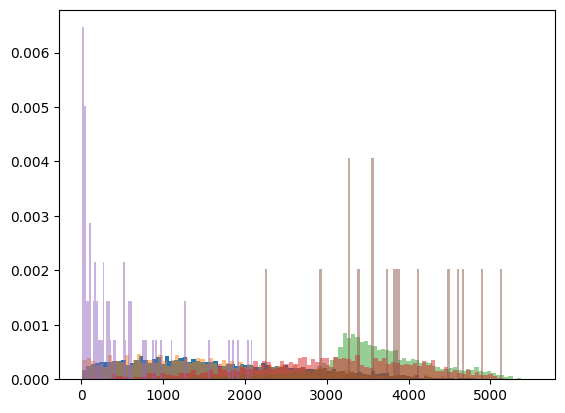

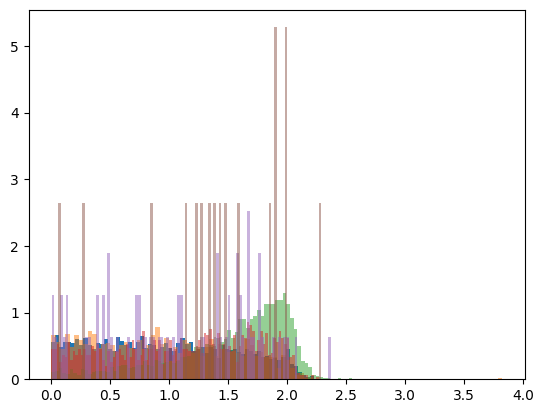

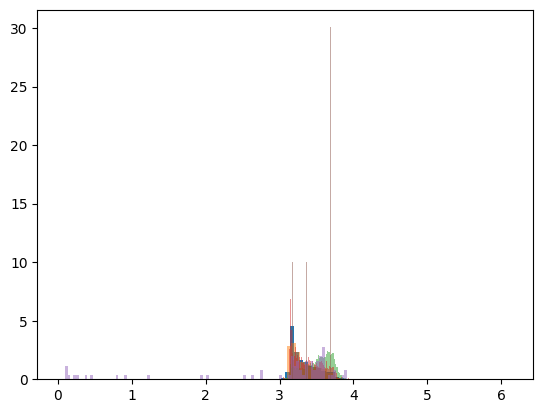

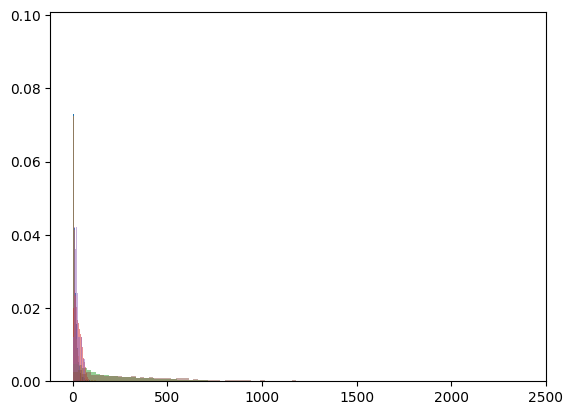

In [48]:
##UPDATE
#muon_E_cut = 4900 and muon_pt_cut = 3200 ONLY, other variables
# Histogram
plt.hist(delete_empty(sig_met_1m[(sig_pt_condition) & (sig_E_condition)]),bins = 100, density = True)
plt.hist(delete_empty(bkg_met_1m[(bkg_pt_condition) & (bkg_E_condition)]),bins = 100,alpha = 0.5, density = True)
plt.hist(delete_empty(bkg_met_1m2[(bkg_pt_condition2) & (bkg_E_condition2)]),bins = 100,alpha = 0.5, density = True)
plt.hist(delete_empty(bkg_met_1mww[(bkg_pt_conditionww) & (bkg_E_conditionww)]),bins = 100,alpha = 0.5, density = True)
plt.hist(delete_empty(bkg_met_1mww2[(bkg_pt_conditionww2) & (bkg_E_conditionww2)]),bins = 100,alpha = 0.5, density = True)
plt.hist(delete_empty(bkg_met_1mww3[(bkg_pt_conditionww3) & (bkg_E_conditionww3)]),bins = 100,alpha = 0.5, density = True)
plt.show()

# Histogram
plt.hist(delete_empty(sig_diff[(sig_pt_condition) & (sig_E_condition)]), bins = 100, density = True)
plt.hist(delete_empty(bkg_diff[(bkg_pt_condition) & (bkg_E_condition)]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_diff2[(bkg_pt_condition2) & (bkg_E_condition2)]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_diffww[(bkg_pt_conditionww) & (bkg_E_conditionww)]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_diffww2[(bkg_pt_conditionww2) & (bkg_E_conditionww2)]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_diffww3[(bkg_pt_conditionww3) & (bkg_E_conditionww3)]),alpha = 0.5, bins = 100, density = True)
plt.show()

# Histogram
plt.hist(delete_empty(sig_R[(sig_pt_condition) & (sig_E_condition)]), bins = 100, density = True)
plt.hist(delete_empty(bkg_R[(bkg_pt_condition) & (bkg_E_condition)]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_R2[(bkg_pt_condition2) & (bkg_E_condition2)]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_Rww[(bkg_pt_conditionww) & (bkg_E_conditionww)]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_Rww2[(bkg_pt_conditionww2) & (bkg_E_conditionww2)]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_Rww3[(bkg_pt_conditionww3) & (bkg_E_conditionww3)]),alpha = 0.5, bins = 100, density = True)
plt.show()


# Histogram
plt.hist(delete_empty(sig_mt2[sig_E_condition]), bins = 100, density = True)
plt.hist(delete_empty(bkg_mt2[bkg_E_condition]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_mt22[bkg_E_condition2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_mt2ww[bkg_E_conditionww]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_mt2ww2[bkg_E_conditionww2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_mt2ww3[bkg_E_conditionww3]),alpha = 0.5, bins = 100, density = True)
plt.show()

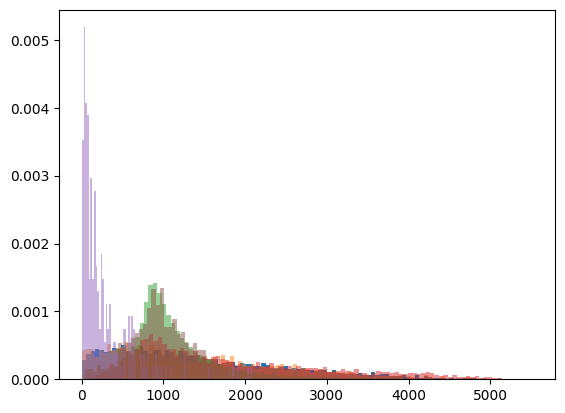

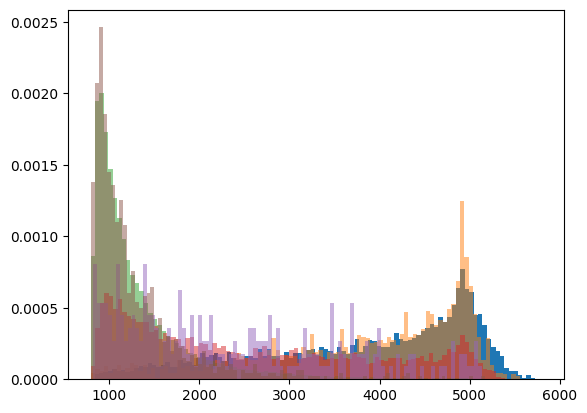

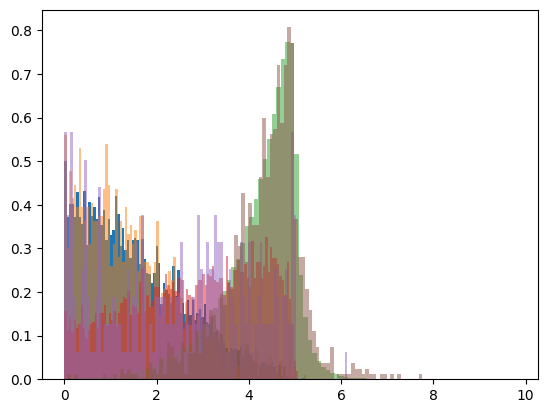

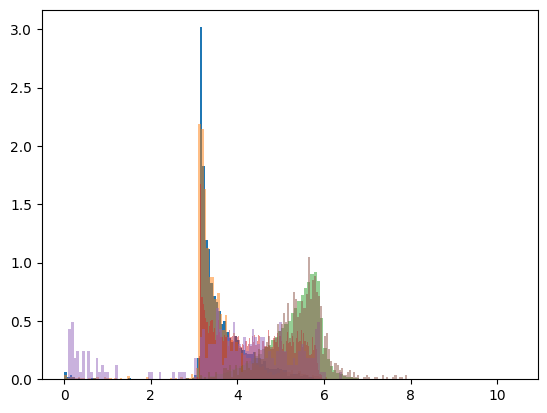

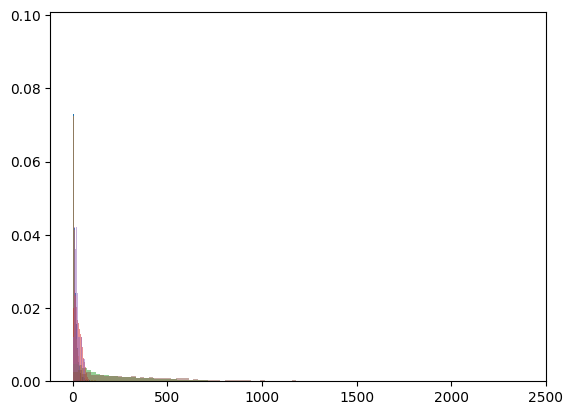

In [50]:
##UPDATE
#muon_E_cut = 4900 ONLY, other variables
# Histogram
plt.hist(delete_empty(sig_met_1m[sig_E_condition]),bins = 100, density = True)
plt.hist(delete_empty(bkg_met_1m[bkg_E_condition]),bins = 100,alpha = 0.5, density = True)
plt.hist(delete_empty(bkg_met_1m2[bkg_E_condition2]),bins = 100,alpha = 0.5, density = True)
plt.hist(delete_empty(bkg_met_1mww[bkg_E_conditionww]),bins = 100,alpha = 0.5, density = True)
plt.hist(delete_empty(bkg_met_1mww2[bkg_E_conditionww2]),bins = 100,alpha = 0.5, density = True)
plt.hist(delete_empty(bkg_met_1mww3[bkg_E_conditionww3]),bins = 100,alpha = 0.5, density = True)
plt.show()

# Histogram
plt.hist(delete_empty(sig_muons_pt_1m[sig_E_condition]), bins = 100, density = True)
plt.hist(delete_empty(bkg_muons_pt_1m[bkg_E_condition]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_muons_pt_1m2[bkg_E_condition2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_muons_pt_1mww[bkg_E_conditionww]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_muons_pt_1mww2[bkg_E_conditionww2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_muons_pt_1mww3[bkg_E_conditionww3]),alpha = 0.5, bins = 100, density = True)
plt.show()


# Histogram
plt.hist(delete_empty(sig_diff[sig_E_condition]), bins = 100, density = True)
plt.hist(delete_empty(bkg_diff[bkg_E_condition]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_diff2[bkg_E_condition2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_diffww[bkg_E_conditionww]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_diffww2[bkg_E_conditionww2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_diffww3[bkg_E_conditionww3]),alpha = 0.5, bins = 100, density = True)
plt.show()

# Histogram
plt.hist(delete_empty(sig_R[sig_E_condition]), bins = 100, density = True)
plt.hist(delete_empty(bkg_R[bkg_E_condition]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_R2[bkg_E_condition2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_Rww[bkg_E_conditionww]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_Rww2[bkg_E_conditionww2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_Rww3[bkg_E_conditionww3]),alpha = 0.5, bins = 100, density = True)
plt.show()

# Histogram
plt.hist(delete_empty(sig_mt2[sig_E_condition]), bins = 100, density = True)
plt.hist(delete_empty(bkg_mt2[bkg_E_condition]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_mt22[bkg_E_condition2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_mt2ww[bkg_E_conditionww]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_mt2ww2[bkg_E_conditionww2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_mt2ww3[bkg_E_conditionww3]),alpha = 0.5, bins = 100, density = True)
plt.show()

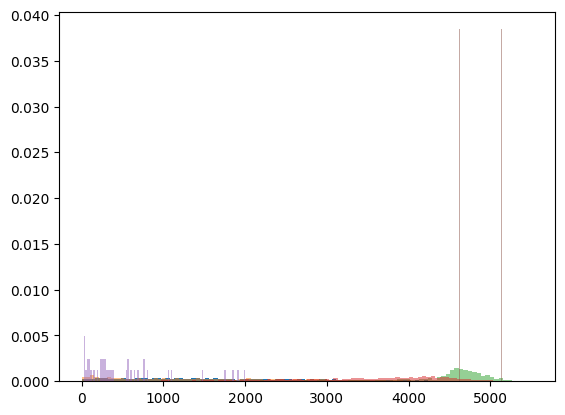

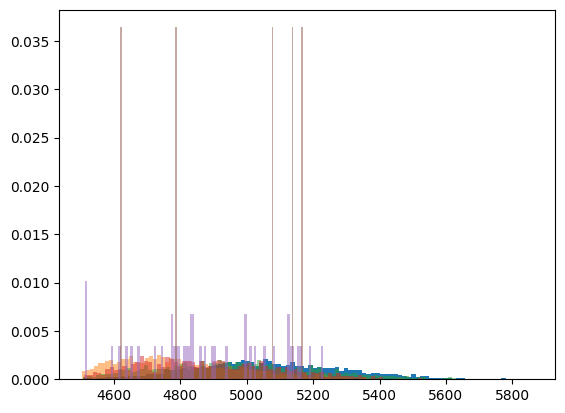

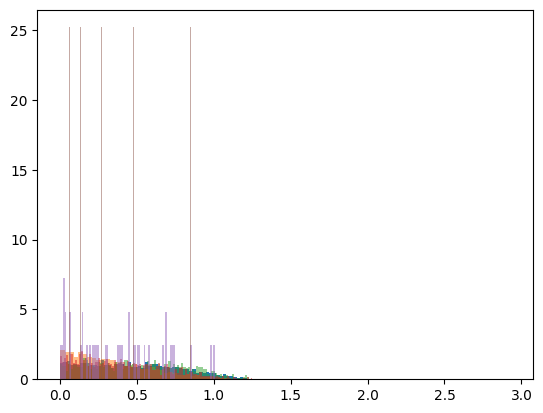

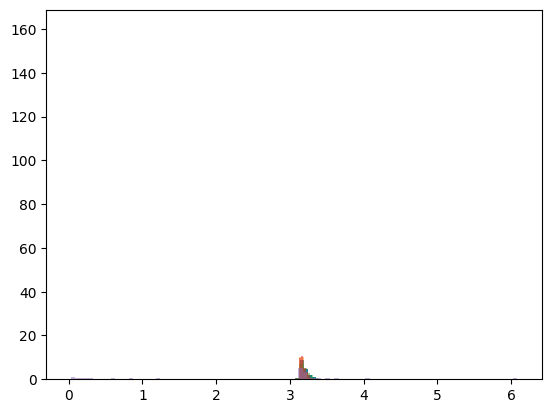

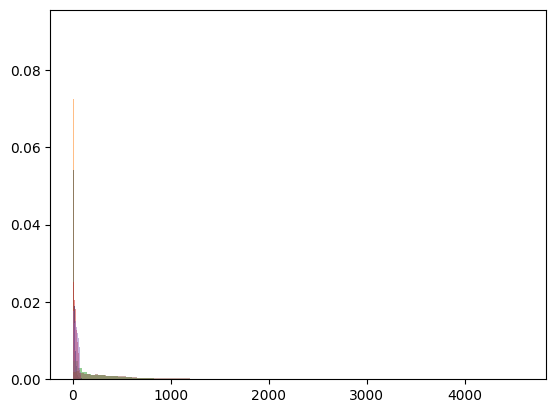

In [52]:
##UPDATE
#muon_pt_cut = 4500  ONLY, other variables
# Histogram
plt.hist(delete_empty(sig_met_1m[sig_pt_condition]),bins = 100, density = True)
plt.hist(delete_empty(bkg_met_1m[bkg_pt_condition]),bins = 100,alpha = 0.5, density = True)
plt.hist(delete_empty(bkg_met_1m2[bkg_pt_condition2]),bins = 100,alpha = 0.5, density = True)
plt.hist(delete_empty(bkg_met_1mww[bkg_pt_conditionww]),bins = 100,alpha = 0.5, density = True)
plt.hist(delete_empty(bkg_met_1mww2[bkg_pt_conditionww2]),bins = 100,alpha = 0.5, density = True)
plt.hist(delete_empty(bkg_met_1mww3[bkg_pt_conditionww3]),bins = 100,alpha = 0.5, density = True)
plt.show()

# Histogram
plt.hist(delete_empty(sig_E[sig_pt_condition]), bins = 100, density = True)
plt.hist(delete_empty(bkg_E[bkg_pt_condition]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_E2[bkg_pt_condition2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_Eww[bkg_pt_conditionww]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_Eww2[bkg_pt_conditionww2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_Eww3[bkg_pt_conditionww3]),alpha = 0.5, bins = 100, density = True)
plt.show()

# Histogram
plt.hist(delete_empty(sig_diff[sig_pt_condition]), bins = 100, density = True)
plt.hist(delete_empty(bkg_diff[bkg_pt_condition]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_diff2[bkg_pt_condition2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_diffww[bkg_pt_conditionww]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_diffww2[bkg_pt_conditionww2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_diffww3[bkg_pt_conditionww3]),alpha = 0.5, bins = 100, density = True)
plt.show()

# Histogram
plt.hist(delete_empty(sig_R[sig_pt_condition]), bins = 100, density = True)
plt.hist(delete_empty(bkg_R[bkg_pt_condition]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_R2[bkg_pt_condition2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_Rww[bkg_pt_conditionww]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_Rww2[bkg_pt_conditionww2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_Rww3[bkg_pt_conditionww3]),alpha = 0.5, bins = 100, density = True)
plt.show()


# Histogram
plt.hist(delete_empty(sig_mt2[sig_E_condition]), bins = 100, density = True)
plt.hist(delete_empty(bkg_mt2[bkg_E_condition]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_mt22[bkg_E_condition2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_mt2ww[bkg_E_conditionww]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_mt2ww2[bkg_E_conditionww2]),alpha = 0.5, bins = 100, density = True)
plt.hist(delete_empty(bkg_mt2ww3[bkg_E_conditionww3]),alpha = 0.5, bins = 100, density = True)
plt.show()

# OLD STUFF BELOW THIS

In [ ]:
val = mt2(
    100, 410, 20,  # Visible 1: mass, px, py
    150, -210, -300,  # Visible 2: mass, px, py
    -200, 280,  # Missing transverse momentum: x, y
    100, 100)  # Invisible 1 mass, invisible 2 mass
print("Expected mT2 = 412.628.  Computed mT2 = ", val)

[[-1.42], [1.41], [-1.09], [4.47], ..., [-0.885], [5.4], [-0.713], [-1.89]]
[[-6.35], [17.3], [0.21], [0.531], ..., [-4.35], [1.26], [67.3], [1.54]]
[[-0.306], [-0.195], [-0.228], [-0.208], ..., [-0.577], [-0.226], [-0.172]]


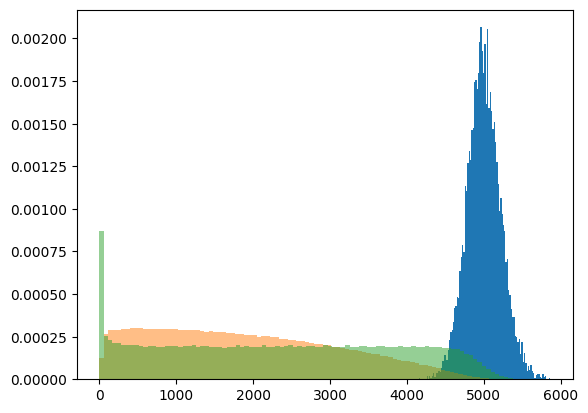

In [53]:
sig_E = compute_E(signal_muons_eta_1m, signal_muons_pt_1m, .10566)
bkg_E = compute_E(bkg_muons_eta_1m, bkg_muons_pt_1m, .10566)
bkg_Eww = compute_E(bkg_muons_eta_1mww, bkg_muons_pt_1mww, .10566)


# Histogram
plt.hist(sig_E, bins = 100,density=True)
plt.hist(bkg_E,alpha = 0.5, bins = 100,density=True)
plt.hist(bkg_Eww,alpha = 0.5, bins = 100,density=True)
plt.show()

In [25]:
true_muons_E_sig = signal_tree["Particle.E"].array()[(signal_tree["Particle.Status"].array() == 1) \
                                  & (signal_tree["Particle.PID"].array() == -13)]
true_muons_pt_sig = signal_tree["Particle.PT"].array()[(signal_tree["Particle.Status"].array() == 1) \
                                  & (signal_tree["Particle.PID"].array() == -13)]
true_muons_eta_sig = signal_tree["Particle.Eta"].array()[(signal_tree["Particle.Status"].array() == 1) \
                                  & (signal_tree["Particle.PID"].array() == -13)]

In [53]:
print(signal_tree["Particle.E"].array()[0].to_list())
print(signal_tree["Particle.Status"].array()[0].to_list())
print(signal_tree["Particle.PID"].array()[0].to_list())

[5000.0, 5000.0, 5000.0, 5000.0, 5000.0, 5000.0, 983.3709716796875, 2946.523193359375, 1070.1060791015625, 1668.6898193359375, 1277.833251953125]
[4, 21, 4, 21, 1, 2, 1, 2, 1, 1, 1]
[13, 13, -13, -13, -13, 15, 16, 111, -211, 22, 22]


In [ ]:
# Histogram
#counts, bins = np.histogram(sig_met_1m,bins = 100)
#plt.hist(bins[:-1], bins, weights=counts*100) #blue
plt.hist(sig_met_1m,bins = 100,alpha = 0.5,density=True) #blue
plt.hist(bkg_met_1m,bins = 100,alpha = 0.5,density=True) #orange
plt.hist(bkg_met_1m2,bins = 100,alpha = 0.5,density=True) #green
plt.hist(bkg_met_1mww,bins = 100,alpha = 0.5,density=True) #red
plt.hist(bkg_met_1mww2,bins = 100,alpha = 0.5,density=True) #purple
plt.hist(bkg_met_1mww3,bins = 100,alpha = 0.5,density=True) #light brown
plt.show()

In [96]:
min_cut_eta = -5 #0.55 min is optimal with no other cuts, but not helpful with E and pt cuts
max_cut_eta = 5 #not helpful with E and pt cuts
min_cut_R = 0 # 3 is optimal with no other cuts, not helpful with E and pt cuts
muon_pt_cut = 3200 #3200
muon_E_cut = 4900 #4900
min_met = 0 #100 Optimal with no other cuts, not helpful with E and pt cuts already imposed
max_mt2 = 50

sig_condition_eta = (sig_diff > min_cut_eta) & (sig_diff < max_cut_eta)
bkg_condition_eta = (bkg_diff > min_cut_eta) & (bkg_diff < max_cut_eta)
bkg_condition_eta2 = (bkg_diff2 > min_cut_eta) & (bkg_diff2 < max_cut_eta)
bkg_condition_etaww = (bkg_diffww > min_cut_eta) & (bkg_diffww < max_cut_eta)
bkg_condition_etaww2 = (bkg_diffww2 > min_cut_eta) & (bkg_diffww2 < max_cut_eta)
bkg_condition_etaww3 = (bkg_diffww3 > min_cut_eta) & (bkg_diffww3 < max_cut_eta)

sig_condition_R = (sig_R > min_cut_R)
bkg_condition_R = (bkg_R > min_cut_R)
bkg_condition_R2 = (bkg_R2 > min_cut_R)
bkg_condition_Rww = (bkg_Rww > min_cut_R)
bkg_condition_Rww2 = (bkg_Rww2 > min_cut_R)
bkg_condition_Rww3 = (bkg_Rww3 > min_cut_R)

sig_pt_condition = (sig_muons_pt_1m > muon_pt_cut)
bkg_pt_condition = (bkg_muons_pt_1m > muon_pt_cut)
bkg_pt_condition2 = (bkg_muons_pt_1m2 > muon_pt_cut)
bkg_pt_conditionww = (bkg_muons_pt_1mww > muon_pt_cut)
bkg_pt_conditionww2 = (bkg_muons_pt_1mww2 > muon_pt_cut)
bkg_pt_conditionww3 = (bkg_muons_pt_1mww3 > muon_pt_cut)

sig_E_condition = (sig_E > muon_E_cut)
bkg_E_condition = (bkg_E > muon_E_cut)
bkg_E_condition2 = (bkg_E2 > muon_E_cut)
bkg_E_conditionww = (bkg_Eww > muon_E_cut)
bkg_E_conditionww2 = (bkg_Eww2 > muon_E_cut)
bkg_E_conditionww3 = (bkg_Eww3 > muon_E_cut)

sig_met_condition = (sig_met_1m > min_met)
bkg_met_condition = (bkg_met_1m > min_met)
bkg_met_condition2 = (bkg_met_1m2 > min_met)
bkg_met_conditionww = (bkg_met_1mww > min_met)
bkg_met_conditionww2 = (bkg_met_1mww2 > min_met)
bkg_met_conditionww3 = (bkg_met_1mww3 > min_met)

sig_mt2_condition = (sig_mt2 < max_mt2)
bkg_mt2_condition = (bkg_mt2 < max_mt2)
bkg_mt2_condition2 = (bkg_mt22 < max_mt2)
bkg_mt2_conditionww = (bkg_mt2ww < max_mt2)
bkg_mt2_conditionww2 = (bkg_mt2ww2 < max_mt2)
bkg_mt2_conditionww3 = (bkg_mt2ww3 < max_mt2)

print("one_muon_sample: ", sig_num, bkg_num, bkg_num2, bkg_numww, bkg_numww2, bkg_numww3)

num_sig_eta = ak.sum(sig_condition_eta)
num_bkg_eta = ak.sum(bkg_condition_eta)
num_bkg_eta2 = ak.sum(bkg_condition_eta2)
num_bkg_etaww = ak.sum(bkg_condition_etaww)
num_bkg_etaww2 = ak.sum(bkg_condition_etaww2)
num_bkg_etaww3 = ak.sum(bkg_condition_etaww3)
print("eta_cut: ", num_sig_eta, num_bkg_eta, num_bkg_eta2, num_bkg_etaww, num_bkg_etaww2, num_bkg_etaww3)

num_sig_R = ak.sum(sig_condition_R)
num_bkg_R = ak.sum(bkg_condition_R)
num_bkg_R2 = ak.sum(bkg_condition_R2)
num_bkg_Rww = ak.sum(bkg_condition_Rww)
num_bkg_Rww2 = ak.sum(bkg_condition_Rww2)
num_bkg_Rww3 = ak.sum(bkg_condition_Rww3)
print("R_cut: ", num_sig_R, num_bkg_R, num_bkg_R2, num_bkg_Rww, num_bkg_Rww2, num_bkg_Rww3)

num_sig_pt = ak.sum(sig_pt_condition)
num_bkg_pt = ak.sum(bkg_pt_condition)
num_bkg_pt2 = ak.sum(bkg_pt_condition2)
num_bkg_ptww = ak.sum(bkg_pt_conditionww)
num_bkg_ptww2 = ak.sum(bkg_pt_conditionww2)
num_bkg_ptww3 = ak.sum(bkg_pt_conditionww3)
print("pt_cut: ", num_sig_pt, num_bkg_pt, num_bkg_pt2, num_bkg_ptww, num_bkg_ptww2, num_bkg_ptww3)

num_sig_E = ak.sum(sig_E_condition)
num_bkg_E = ak.sum(bkg_E_condition)
num_bkg_E2 = ak.sum(bkg_E_condition2)
num_bkg_Eww = ak.sum(bkg_E_conditionww)
num_bkg_Eww2 = ak.sum(bkg_E_conditionww2)
num_bkg_Eww3 = ak.sum(bkg_E_conditionww3)
print("E_cut: ", num_sig_E, num_bkg_E, num_bkg_E2, num_bkg_Eww, num_bkg_Eww2, num_bkg_Eww3)

num_sig_met = ak.sum(sig_met_condition)
num_bkg_met = ak.sum(bkg_met_condition)
num_bkg_met2 = ak.sum(bkg_met_condition2)
num_bkg_metww = ak.sum(bkg_met_conditionww)
num_bkg_metww2 = ak.sum(bkg_met_conditionww2)
num_bkg_metww3 = ak.sum(bkg_met_conditionww3)
print("met_cut: ", num_sig_met, num_bkg_met, num_bkg_met2, num_bkg_metww, num_bkg_metww2, num_bkg_metww3)

num_sig_mt2 = ak.sum(sig_mt2_condition)
num_bkg_mt2 = ak.sum(bkg_mt2_condition)
num_bkg_mt22 = ak.sum(bkg_mt2_condition2)
num_bkg_mt2ww = ak.sum(bkg_mt2_conditionww)
num_bkg_mt2ww2 = ak.sum(bkg_mt2_conditionww2)
num_bkg_mt2ww3 = ak.sum(bkg_mt2_conditionww3)
print("mt2_cut: ", num_sig_mt2, num_bkg_mt2, num_bkg_mt22, num_bkg_mt2ww, num_bkg_mt2ww2, num_bkg_mt2ww3)

num_sig_ptE = ak.sum((sig_pt_condition) & (sig_E_condition))
num_bkg_ptE = ak.sum((bkg_pt_condition) & (bkg_E_condition))
num_bkg_ptE2 = ak.sum((bkg_pt_condition2) & (bkg_E_condition2))
num_bkg_ptEww = ak.sum((bkg_pt_conditionww) & (bkg_E_conditionww))
num_bkg_ptEww2 = ak.sum((bkg_pt_conditionww2) & (bkg_E_conditionww2))
num_bkg_ptEww3 = ak.sum((bkg_pt_conditionww3) & (bkg_E_conditionww3))
print("PT_and_E_cut: ", num_sig_ptE, num_bkg_ptE, num_bkg_ptE2, num_bkg_ptEww, num_bkg_ptEww2, num_bkg_ptEww3)

num_sig_both = ak.sum((sig_condition_eta) & (sig_condition_R) & (sig_pt_condition) & (sig_E_condition) & (sig_met_condition) & (sig_mt2_condition))
num_bkg_both = ak.sum((bkg_condition_eta) & (bkg_condition_R) & (bkg_pt_condition) & (bkg_E_condition) & (bkg_met_condition) & (bkg_mt2_condition))
num_bkg_both2 = ak.sum((bkg_condition_eta2) & (bkg_condition_R2) & (bkg_pt_condition2) & (bkg_E_condition2) & (bkg_met_condition2) & (bkg_mt2_condition2))
num_bkg_bothww = ak.sum((bkg_condition_etaww) & (bkg_condition_Rww) & (bkg_pt_conditionww) & (bkg_E_conditionww) & (bkg_met_conditionww) & (bkg_mt2_conditionww))
num_bkg_bothww2 = ak.sum((bkg_condition_etaww2) & (bkg_condition_Rww2) & (bkg_pt_conditionww2) & (bkg_E_conditionww2) & (bkg_met_conditionww2) & (bkg_mt2_conditionww2))
num_bkg_bothww3 = ak.sum((bkg_condition_etaww3) & (bkg_condition_Rww3) & (bkg_pt_conditionww3) & (bkg_E_conditionww3) & (bkg_met_conditionww3) & (bkg_mt2_conditionww3))
print("All_cut: ", num_sig_both, num_bkg_both, num_bkg_both2, num_bkg_bothww, num_bkg_bothww2, num_bkg_bothww3)

print("Total_Events: ", sig_num, bkg_num, bkg_num2, bkg_numww, bkg_numww2, bkg_numww3)


bkg_xs = np.array([0.00104054000037051*ttom_decay*t_tag*ttoj_decay*num_bkg/bkg_num for num_bkg in \
                   [num_bkg_eta, num_bkg_met, num_bkg_R, num_bkg_pt, num_bkg_E, num_bkg_both]])
bkg_xs2 = np.array([0.0086335991259087*t_tag*ttoj_decay*num_bkg2/bkg_num2 for num_bkg2 in \
                   [num_bkg_eta, num_bkg_met, num_bkg_R, num_bkg_pt, num_bkg_E, num_bkg_both]])
bkg_xsww = np.array([ 0.05892670097476*wtom_decay*wtot_decay*t_tag*ttoj_decay*num_bkgww/bkg_numww for num_bkgww in \
                   [num_bkg_etaww, num_bkg_metww, num_bkg_Rww, num_bkg_ptww, num_bkg_Eww, num_bkg_bothww]])
bkg_xsww2 = np.array([ 0.05892670097476*j_mistag*wtom_decay*wtoj_decay*num_bkgww2/bkg_numww2 for num_bkgww2 in \
                   [num_bkg_etaww2, num_bkg_metww2, num_bkg_Rww2, num_bkg_ptww2, num_bkg_Eww2, num_bkg_bothww2]])
bkg_xsww3 = np.array([ 0.030682170647439774*j_mistag*num_bkgww3/bkg_numww3 for num_bkgww3 in \
                   [num_bkg_etaww3, num_bkg_metww3, num_bkg_Rww3, num_bkg_ptww3, num_bkg_Eww3, num_bkg_bothww3]])
#bkg_BB = 0.007963
#bkg_BB2 = 1.063
#bkg_BB3 = 1.058
sig_xs = np.array([1.0129299999999999*t_tag*ttoj_decay*num_sig/sig_num for num_sig in \
                   [num_sig_eta, num_sig_met, num_sig_R, num_sig_pt, num_sig_E, num_sig_both]])

print((bkg_xs + bkg_xs2 + bkg_xsww + bkg_xsww2 + bkg_xsww3)*(10**7))
print(sig_xs*(10**7))
c_rescale = ((bkg_xs + bkg_xs2 + bkg_xsww + bkg_xsww2 + bkg_xsww3)**(1/4))/25.1487/np.sqrt(sig_xs)
New_scale = 10/np.sqrt(c_rescale)
print(New_scale)

one_muon_sample:  10000 1000000 1000000 1000000 50000 10000
eta_cut:  9872 828507 777764 176223 9213 2701
R_cut:  9875 828636 900776 177300 9299 3492
pt_cut:  6992 54995 16235 10459 479 40
E_cut:  7633 269335 281315 48983 2468 986
met_cut:  9875 828636 900776 177300 9299 3492
mt2_cut:  9652 822196 201639 155589 7050 329
PT_and_E_cut:  6045 41308 12438 8018 367 32
All_cut:  5974 41058 2421 6916 360 0
Total_Events:  10000 1000000 1000000 1000000 50000 10000
[40316.63123167 40813.34865903 40813.34865903  2583.86743002
 13132.97891714  1907.47359634]
[5183015.9756672 5184591.0413    5184591.0413    3670952.9681792
 4007491.9917208 3136480.6967824]
[ 84.76525589  84.64203917  84.64203917 109.62729462  91.44933043
 109.47403055]
